# Viabilidad económica de plantas de biometano en Huesca 

El siguiente notebook parte del archivo idoneidad y consta con tres partes: la proyeccion de los censos de animales, la eleccion de las celdas optimas y en analisis financiero.

- La parte de **proyecciones y selección de celdas**: la serie histórica del censo porcino del MAPA, la comparación de modelos de forecasting, la proyección del stock a 15 años y los modelos de clasificación/regresión sobre las celdas viables.
- De la parte de **análisis económico**: el estudio de inversión — CAPEX geoespacial, curva de arranque de la planta, dimensionamiento sitio a sitio — y la simulación de **Monte Carlo**, que es la que responde la pregunta: *¿qué probabilidad hay de perder plata?*

Pasos del proceso:

1. Serie histórica del censo porcino de Huesca (MAPA).
2. Proyección del stock a 15 años con el mejor de cinco modelos.
3. Economía preliminar celda a celda sobre **todas** las celdas viables del análisis geoespacial, con los **mismos supuestos centrales del modelo financiero** , y detección de las óptimas. Modelos de apoyo para ver qué variables pesan.
4. Estudio financiero con Monte Carlo sobre **todas las celdas óptimas**: VAN, TIR, escala óptima de planta.
5. Exportación de resultados y recomendación final de inversión.




## 0. Configuración y rutas

In [1]:
import json
import requests
import urllib3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", "{:,.2f}".format)

rng = np.random.default_rng(42)
N_SIM = 25_000   # simulaciones de Monte Carlo por combinación sitio x escala

print(f"Monte Carlo: {N_SIM:,} simulaciones por combinación sitio x escala")

Monte Carlo: 25,000 simulaciones por combinación sitio x escala


In [ ]:
# Rutas dinámicas: subimos desde la carpeta actual hasta encontrar la raíz
# del proyecto (la que tiene data/processed). Así el notebook corre igual
# desde notebooks/03_viability, desde la raíz o desde donde sea.

def encontrar_raiz():
    aca = Path.cwd().resolve()
    for carpeta in [aca, *aca.parents]:
        if (carpeta / "data" / "processed").is_dir():
            return carpeta
    raise FileNotFoundError(
        f"No encontré la carpeta data/processed subiendo desde {aca}. "
        "Asegurate de correr el notebook dentro del proyecto, o definí RAIZ a mano."
    )

RAIZ            = encontrar_raiz()
DIR_PROCESSED   = RAIZ / "data" / "processed"
DIR_RAW_PORCINO = RAIZ / "data" / "raw" / "01_ganado_porcino"
DIR_DELIM       = RAIZ / "data" / "raw" / "delimitations"

print(f"Raíz del proyecto: {RAIZ}\n")

ARCHIVOS_NECESARIOS = [
    DIR_PROCESSED / "viables_interseccion.gpkg",
    DIR_RAW_PORCINO / "clasificacion_porcino.gpkg",
    DIR_DELIM / "Huesca_Delimitacion.geojson",
]
for ruta in ARCHIVOS_NECESARIOS:
    estado = "ok   " if ruta.exists() else "FALTA"
    print(f"[{estado}] {ruta.relative_to(RAIZ)}")

Raíz del proyecto: C:\Users\FGonella\Documents\Python\Curso Master Archivos\00_TFM\Biomethane-Plant-Design-main

[ok   ] data\processed\viables_interseccion.gpkg
[ok   ] data\raw\01_ganado_porcino\clasificacion_porcino.gpkg
[ok   ] data\raw\delimitations\Huesca_Delimitacion.geojson


## 1. Censo porcino de Huesca — serie histórica (MAPA)

Bajamos la encuesta de efectivos de ganado del MAPA y nos quedamos con el porcino de Huesca (código de provincia 722). La serie es semestral desde 2010, o sea unos 30 puntos. No es un montón, pero para capturar la tendencia provincial alcanza.

Si el Excel ya está bajado de una corrida anterior, no lo vuelve a descargar.

In [3]:
URL_MAPA = ("https://www.mapa.gob.es/dam/mapa/contenido/estadisticas/temas/"
            "estadisticas-agrarias/3.ganaderia/encuestas-ganaderas/efectivos_ganado.xlsx")
archivo_ganado = DIR_RAW_PORCINO / "EFECTIVOS_GANADO.xlsx"

if archivo_ganado.exists():
    print(f"Ya estaba bajado: {archivo_ganado.name}")
else:
    print("Bajando encuesta de efectivos del MAPA...")
    respuesta = requests.get(URL_MAPA, headers={"User-Agent": "Mozilla/5.0"}, verify=False)
    respuesta.raise_for_status()
    archivo_ganado.write_bytes(respuesta.content)
    print(f"Guardado en: {archivo_ganado.relative_to(RAIZ)}")

df = pd.read_excel(archivo_ganado, sheet_name="data", engine="openpyxl")

huesca_porcino = df[
    (df["COMUNIDAD-PROVINCIA"] == 722) &
    (df["ESPECIE"] == "Porcino")
].copy()

print(f"Filas tras filtro Huesca-porcino: {len(huesca_porcino)}")
print(huesca_porcino[["AÑO", "MES", "VARIABLE", "VALOR"]].head())

Ya estaba bajado: EFECTIVOS_GANADO.xlsx
Filas tras filtro Huesca-porcino: 1209
        AÑO  MES       VARIABLE        VALOR
28959  2010    5    01Tanimales 2,379,953.11
28960  2010    5     02Lechones   675,390.15
28961  2010    5  03Cerdos20a49   638,089.27
28962  2010    5        04TCebo   905,651.26
28963  2010    5    05Cebo50a79   352,770.64


In [4]:
VARS_CLAVE = ["01Tanimales", "02Lechones", "03Cerdos20a49", "04TCebo", "08Verracos", "09TCerdasR"]

pivot = huesca_porcino[huesca_porcino["VARIABLE"].isin(VARS_CLAVE)].pivot_table(
    index=["AÑO", "MES"], columns="VARIABLE", values="VALOR", aggfunc="first"
).reset_index()

pivot = pivot.sort_values(["AÑO", "MES"]).reset_index(drop=True)
pivot["fecha"] = pd.to_datetime(pivot["AÑO"].astype(str) + "-" + pivot["MES"].astype(str) + "-01")
pivot = pivot[["fecha", "AÑO", "MES"] + VARS_CLAVE]
pivot.columns = ["fecha", "anio", "mes", "total_animales", "lechones", "cerdos_20_49kg",
                 "cebo_total", "verracos", "cerdas_reproductoras"]

print(pivot.shape)
pivot.head()

(31, 9)


,fecha,anio,mes,total_animales,lechones,cerdos_20_49kg,cebo_total,verracos,cerdas_reproductoras
0,2010-05-01,2010,5,"2,379,953.11","675,390.15","638,089.27","905,651.26","1,230.30","159,592.13"
1,2010-11-01,2010,11,"2,588,667.00","615,849.00","757,456.00","1,065,504.00",913.00,"148,945.00"
2,2011-05-01,2011,5,"2,588,667.00","615,849.00","757,456.00","1,065,504.00",913.00,"148,945.00"
3,2011-11-01,2011,11,"2,435,530.00","586,759.00","754,899.00","960,853.00",899.00,"132,120.00"
4,2012-05-01,2012,5,"2,752,946.00","672,880.00","926,835.00","997,173.00",906.00,"155,152.00"


In [5]:
# Control de calidad rápido: nulos y huecos en la serie semestral

print("=== NULOS ===")
print(pivot.isnull().sum())

periodos_esperados = pd.date_range(start=pivot["fecha"].min(), end=pivot["fecha"].max(), freq="6MS")
faltantes = set(periodos_esperados) - set(pivot["fecha"])
print(f"\nPeriodos esperados: {len(periodos_esperados)} | Reales: {len(pivot)} | Faltantes: {sorted(faltantes)}")

print("\n=== ESTADÍSTICAS total_animales ===")
print(pivot["total_animales"].describe().round(0))

pivot.to_csv(DIR_PROCESSED / "huesca_porcino_serie.csv", index=False)
print("\nGuardado: data/processed/huesca_porcino_serie.csv")

=== NULOS ===
fecha                   0
anio                    0
mes                     0
total_animales          0
lechones                0
cerdos_20_49kg          0
cebo_total              0
verracos                0
cerdas_reproductoras    0
dtype: int64

Periodos esperados: 31 | Reales: 31 | Faltantes: []

=== ESTADÍSTICAS total_animales ===
count          31.00
mean    3,778,977.00
std       964,349.00
min     2,379,953.00
25%     2,848,762.00
50%     3,831,327.00
75%     4,712,356.00
max     5,183,335.00
Name: total_animales, dtype: float64

Guardado: data/processed/huesca_porcino_serie.csv


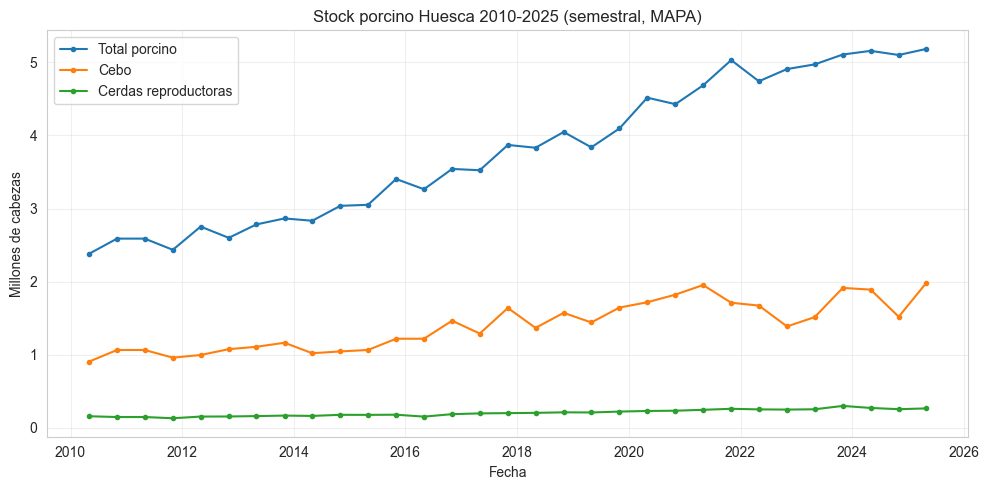

In [6]:
pivot["fecha"] = pd.to_datetime(pivot["fecha"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pivot["fecha"].to_numpy(), (pivot["total_animales"] / 1e6).to_numpy(),
        marker="o", markersize=3, label="Total porcino")
ax.plot(pivot["fecha"].to_numpy(), (pivot["cebo_total"] / 1e6).to_numpy(),
        marker="o", markersize=3, label="Cebo")
ax.plot(pivot["fecha"].to_numpy(), (pivot["cerdas_reproductoras"] / 1e6).to_numpy(),
        marker="o", markersize=3, label="Cerdas reproductoras")
ax.set_xlabel("Fecha")
ax.set_ylabel("Millones de cabezas")
ax.set_title("Stock porcino Huesca 2010-2025 (semestral, MAPA)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "serie_huesca_porcino.png", dpi=130)
plt.show()

## 2. Proyección del stock porcino a 15 años

Acá está el corazón de la parte de forecasting. Probamos cinco modelos (regresión lineal, polinómica, SVR, Random Forest y Gradient Boosting), tuneamos hiperparámetros con Optuna y validamos con ventana temporal expansiva — nada de mezclar pasado y futuro, que en series de tiempo eso es hacerse trampa al solitario.

El criterio de selección es el MAPE sobre los últimos 6 semestres (test). Un detalle que conviene tener presente: los modelos de árboles no extrapolan más allá del rango que vieron en entrenamiento, así que en una serie con tendencia clara suelen perder contra la regresión lineal. Es justo lo que se termina viendo en los resultados.

In [7]:
import optuna
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.base import clone

optuna.logging.set_verbosity(optuna.logging.WARNING)

serie = pivot[["fecha", "total_animales"]].rename(
    columns={"fecha": "ds", "total_animales": "y"}).copy()
serie["ds"] = pd.to_datetime(serie["ds"])
serie["y"]  = pd.to_numeric(serie["y"], errors="coerce")
serie = serie.dropna(subset=["ds", "y"]).reset_index(drop=True)
serie["t"]  = np.arange(len(serie))

N_TEST              = 6
N_TRIALS            = 100
VENTANA_INICIAL     = 16
HORIZONTE           = 1
PERIODOS_PROYECCION = 30  # 15 años x 2 semestres

train = serie.iloc[:-N_TEST].copy()
test  = serie.iloc[-N_TEST:].copy()
X_train, y_train = train[["t"]], train["y"]
X_test,  y_test  = test[["t"]],  test["y"]

def crear_modelo(nombre, params=None):
    params = params or {}
    if nombre == "Regresion Lineal":
        return LinearRegression()
    if nombre == "Regresion Polinomica":
        return Pipeline([("poly", PolynomialFeatures(degree=params["degree"],
                                                      include_bias=False)),
                         ("model", LinearRegression())])
    if nombre == "SVR":
        return Pipeline([("scaler", StandardScaler()),
                         ("model", SVR(kernel="rbf", C=params["C"],
                                       epsilon=params["epsilon"],
                                       gamma=params["gamma"]))])
    if nombre == "Random Forest":
        return RandomForestRegressor(n_estimators=params["n_estimators"],
                                     max_depth=params["max_depth"],
                                     min_samples_leaf=params["min_samples_leaf"],
                                     random_state=42)
    if nombre == "Gradient Boosting":
        return GradientBoostingRegressor(n_estimators=params["n_estimators"],
                                         learning_rate=params["learning_rate"],
                                         max_depth=params["max_depth"],
                                         min_samples_leaf=params["min_samples_leaf"],
                                         random_state=42)

def calcular_metricas(y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100
    return mae, rmse, mape

def validacion_temporal(modelo, datos, ventana_inicial=16, horizonte=1):
    # ventana expansiva: entreno hasta i, predigo el siguiente semestre
    metricas = []
    for i in range(ventana_inicial, len(datos) - horizonte + 1):
        m = clone(modelo)
        m.fit(datos.iloc[:i][["t"]], datos.iloc[:i]["y"])
        y_pred = m.predict(datos.iloc[i:i+horizonte][["t"]])
        mae, rmse, mape = calcular_metricas(datos.iloc[i:i+horizonte]["y"], y_pred)
        metricas.append({"MAE": mae, "RMSE": rmse, "MAPE": mape})
    df_m = pd.DataFrame(metricas)
    return {"MAE_CV": df_m["MAE"].mean(), "RMSE_CV": df_m["RMSE"].mean(),
            "MAPE_CV": df_m["MAPE"].mean()}

objetivos = {
    "Regresion Polinomica": lambda t: validacion_temporal(
        crear_modelo("Regresion Polinomica",
                     {"degree": t.suggest_int("degree", 2, 3)}),
        train, VENTANA_INICIAL, HORIZONTE)["MAPE_CV"],
    "SVR": lambda t: validacion_temporal(
        crear_modelo("SVR", {"C": t.suggest_float("C", 1, 1000, log=True),
                             "epsilon": t.suggest_float("epsilon", 0.01, 0.2),
                             "gamma": t.suggest_float("gamma", 0.001, 1, log=True)}),
        train, VENTANA_INICIAL, HORIZONTE)["MAPE_CV"],
    "Random Forest": lambda t: validacion_temporal(
        crear_modelo("Random Forest",
                     {"n_estimators": t.suggest_int("n_estimators", 100, 500),
                      "max_depth": t.suggest_int("max_depth", 2, 6),
                      "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 5)}),
        train, VENTANA_INICIAL, HORIZONTE)["MAPE_CV"],
    "Gradient Boosting": lambda t: validacion_temporal(
        crear_modelo("Gradient Boosting",
                     {"n_estimators": t.suggest_int("n_estimators", 50, 500),
                      "learning_rate": t.suggest_float("learning_rate", 0.01, 0.2, log=True),
                      "max_depth": t.suggest_int("max_depth", 1, 4),
                      "min_samples_leaf": t.suggest_int("min_samples_leaf", 1, 5)}),
        train, VENTANA_INICIAL, HORIZONTE)["MAPE_CV"],
}

mejores_parametros = {"Regresion Lineal": {}}
resultados = []

for nombre, funcion_objetivo in [("Regresion Lineal", None)] + list(objetivos.items()):
    if funcion_objetivo is not None:
        study = optuna.create_study(direction="minimize",
                                    sampler=optuna.samplers.TPESampler(seed=42))
        study.optimize(funcion_objetivo, n_trials=N_TRIALS)
        mejores_parametros[nombre] = study.best_params

    modelo = crear_modelo(nombre, mejores_parametros[nombre])
    cv_metrics = validacion_temporal(modelo, train, VENTANA_INICIAL, HORIZONTE)
    modelo.fit(X_train, y_train)
    mae_t, rmse_t, mape_t = calcular_metricas(y_test, modelo.predict(X_test))

    resultados.append({"modelo": nombre,
                       "MAE_CV":   cv_metrics["MAE_CV"],
                       "RMSE_CV":  cv_metrics["RMSE_CV"],
                       "MAPE_CV":  cv_metrics["MAPE_CV"],
                       "MAE_TEST": mae_t,
                       "RMSE_TEST": rmse_t,
                       "MAPE_TEST": mape_t,
                       "hiperparametros": mejores_parametros[nombre]})

resultados_finales = pd.DataFrame(resultados).sort_values(
    "MAPE_TEST", ascending=True).reset_index(drop=True)

mejor_modelo_nombre = resultados_finales.iloc[0]["modelo"]
mejor_modelo_params = mejores_parametros[mejor_modelo_nombre]

mejor_modelo = crear_modelo(mejor_modelo_nombre, mejor_modelo_params)
mejor_modelo.fit(X_train, y_train)
test = test.copy()
test["yhat"] = mejor_modelo.predict(X_test)

comparacion = test[["ds", "y", "yhat"]].copy()
comparacion["error_pct"] = ((comparacion["yhat"] - comparacion["y"])
                             / comparacion["y"] * 100).round(2)
mae_final, rmse_final, mape_final = calcular_metricas(
    comparacion["y"], comparacion["yhat"])

# Reentreno con toda la serie y proyecto 30 semestres (15 años)
mejor_modelo_final = crear_modelo(mejor_modelo_nombre, mejor_modelo_params)
mejor_modelo_final.fit(serie[["t"]], serie["y"])

ultimo_t = serie["t"].max()
fechas_futuras = [serie["ds"].max() + pd.DateOffset(months=6 * i)
                  for i in range(1, PERIODOS_PROYECCION + 1)]
futuro = pd.DataFrame({
    "ds": fechas_futuras,
    "t":  np.arange(ultimo_t + 1, ultimo_t + PERIODOS_PROYECCION + 1)
})
futuro["yhat"] = mejor_modelo_final.predict(futuro[["t"]])

print("=== MÉTRICAS POR MODELO (orden por MAPE_TEST) ===")
print(resultados_finales[["modelo", "MAPE_CV", "MAPE_TEST",
                           "hiperparametros"]].to_string(index=False))
print(f"\nModelo elegido: {mejor_modelo_nombre}")
print(f"MAPE test:      {mape_final:.2f}%")

=== MÉTRICAS POR MODELO (orden por MAPE_TEST) ===
              modelo  MAPE_CV  MAPE_TEST                                                                                    hiperparametros
    Regresion Lineal     4.34       1.64                                                                                                 {}
       Random Forest     5.12       4.94                                       {'n_estimators': 128, 'max_depth': 3, 'min_samples_leaf': 1}
   Gradient Boosting     4.85       4.95 {'n_estimators': 118, 'learning_rate': 0.05384672105843426, 'max_depth': 1, 'min_samples_leaf': 1}
Regresion Polinomica     3.90       9.80                                                                                      {'degree': 2}
                 SVR    29.29      32.70             {'C': 995.6055660659023, 'epsilon': 0.12634476611677242, 'gamma': 0.38556571812244966}

Modelo elegido: Regresion Lineal
MAPE test:      1.64%


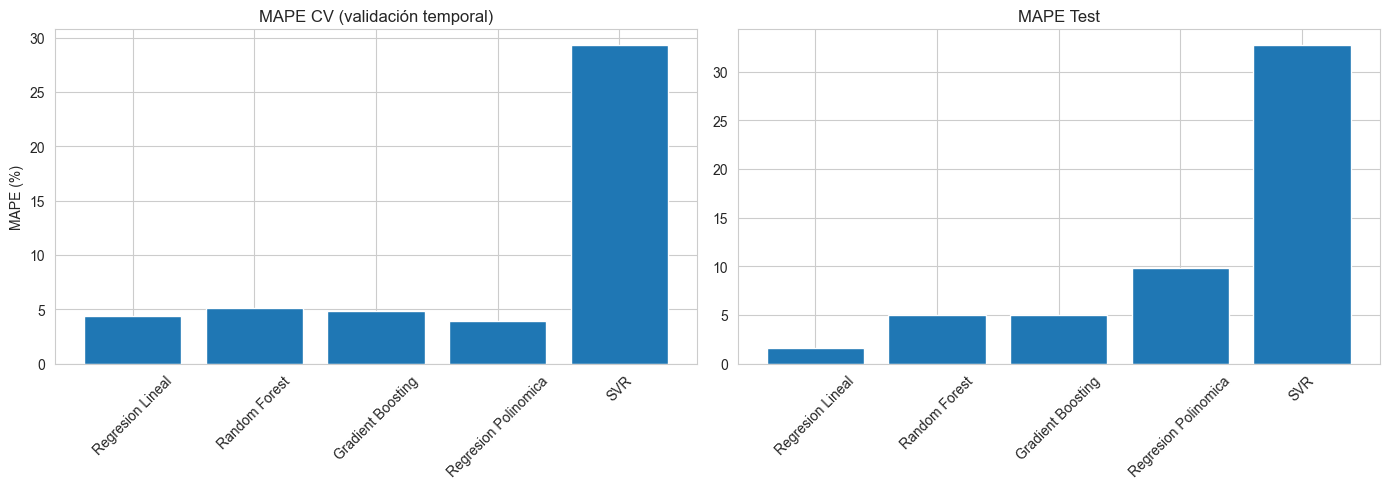

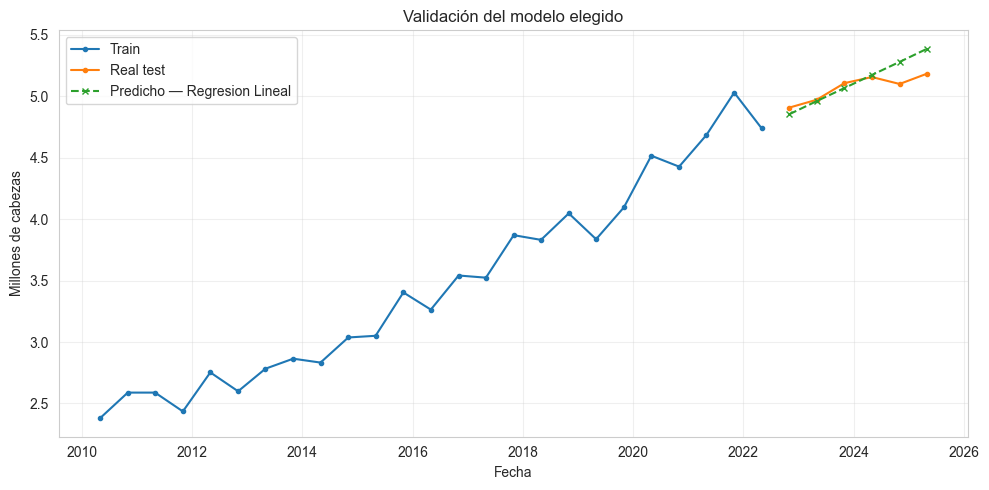

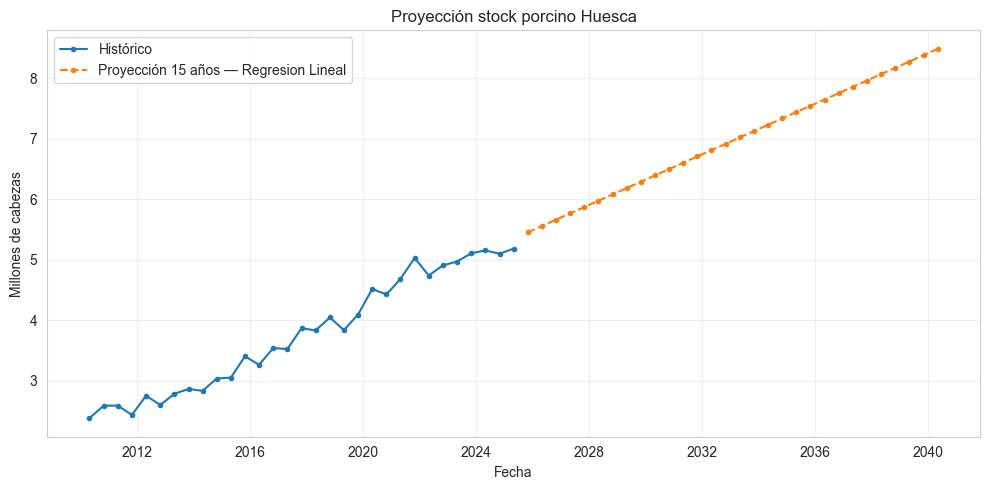

In [8]:
train["ds"]  = pd.to_datetime(train["ds"])
test["ds"]   = pd.to_datetime(test["ds"])
serie["ds"]  = pd.to_datetime(serie["ds"])
futuro["ds"] = pd.to_datetime(futuro["ds"])

# 1. Comparativa MAPE por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(resultados_finales["modelo"].to_numpy(),
            resultados_finales["MAPE_CV"].to_numpy())
axes[0].set_title("MAPE CV (validación temporal)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("MAPE (%)")
axes[1].bar(resultados_finales["modelo"].to_numpy(),
            resultados_finales["MAPE_TEST"].to_numpy())
axes[1].set_title("MAPE Test")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "comparacion_modelos.png", dpi=130)
plt.show()

# 2. Validación: real vs predicho
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train["ds"].to_numpy(), (train["y"] / 1e6).to_numpy(),
        marker="o", markersize=3, label="Train")
ax.plot(test["ds"].to_numpy(), (test["y"] / 1e6).to_numpy(),
        marker="o", markersize=3, label="Real test")
ax.plot(test["ds"].to_numpy(), (test["yhat"] / 1e6).to_numpy(),
        marker="x", markersize=5, linestyle="--",
        label=f"Predicho — {mejor_modelo_nombre}")
ax.set_title("Validación del modelo elegido")
ax.set_xlabel("Fecha"); ax.set_ylabel("Millones de cabezas")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "validacion_modelo_elegido.png", dpi=130)
plt.show()

# 3. Proyección a 15 años
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(serie["ds"].to_numpy(), (serie["y"] / 1e6).to_numpy(),
        marker="o", markersize=3, label="Histórico")
ax.plot(futuro["ds"].to_numpy(), (futuro["yhat"] / 1e6).to_numpy(),
        marker="o", markersize=3, linestyle="--",
        label=f"Proyección 15 años — {mejor_modelo_nombre}")
ax.set_title("Proyección stock porcino Huesca")
ax.set_xlabel("Fecha"); ax.set_ylabel("Millones de cabezas")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "proyeccion_porcino_15anios.png", dpi=130)
plt.show()

In [9]:
futuro.to_csv(DIR_PROCESSED / "proyeccion_porcino_15anios.csv", index=False)

stock_actual   = float(serie["y"].iloc[-1])
stock_proy_15a = float(futuro["yhat"].iloc[-1])
variacion_pct  = (stock_proy_15a - stock_actual) / stock_actual * 100

print(f"Modelo usado:            {mejor_modelo_nombre}")
print(f"Stock actual:            {stock_actual:,.0f} cabezas")
print(f"Stock proyectado (2040): {stock_proy_15a:,.0f} cabezas")
print(f"Variación proyectada:    {variacion_pct:+.1f}%")
print(f"\nExportado: data/processed/proyeccion_porcino_15anios.csv ({len(futuro)} periodos)")

Modelo usado:            Regresion Lineal
Stock actual:            5,183,335 cabezas
Stock proyectado (2040): 8,487,304 cabezas
Variación proyectada:    +63.7%

Exportado: data/processed/proyeccion_porcino_15anios.csv (30 periodos)


## 3. Economía preliminar celda a celda y detección de óptimas

Del análisis geoespacial viene el conjunto de celdas que ya pasaron todos los filtros (Red Natura, pendiente, suelo, distancia a núcleos, etc. — el recuento lo imprime la celda siguiente). Para cada una calculamos cuánto purín hay disponible en un radio de 10 km, cuánto biometano sale de eso, y qué CAPEX implica montar ahí una planta (equipo + conexión al gasoducto).

**Los supuestos económicos son exactamente los valores centrales (moda) de las distribuciones del Monte Carlo de la sección 4.2** — mismo rendimiento, mismo precio, mismos costes operativos y de conexión. Así el filtro de óptimas y el estudio financiero hablan el mismo idioma, y los tres escenarios de precio son el mínimo / moda / máximo de la misma triangular que después sortea el Monte Carlo.

Las "óptimas" salen de cruzar tres criterios:

1. **Robustez del suministro**: stock porcino proyectado a 2040 en el entorno de la celda por encima de la mediana. La proyección se usa acá como filtro de que la materia prima va a seguir estando — no para calcular ingresos.
2. **Conexión barata**: gasoducto a 2 km o menos.
3. **Rentabilidad preliminar**: margen anual del escenario base en el cuartil superior (y siempre positivo).

Los umbrales relativos (mediana, cuartil) se calculan sobre los datos de cada corrida, así que no hay números mágicos que se desactualicen.


In [10]:
viables = gpd.read_file(DIR_PROCESSED / "viables_interseccion.gpkg").to_crs("EPSG:25830")
porcino = gpd.read_file(DIR_RAW_PORCINO / "clasificacion_porcino.gpkg").to_crs("EPSG:25830")
sindex_porcino = porcino.sindex   # índice espacial, acelera bastante los buffers

print(f"Celdas viables cargadas: {len(viables)}")
print(f"Explotaciones porcinas:  {len(porcino)}")

# ── Supuestos técnicos y económicos: los MISMOS del modelo financiero ─────
# Valores centrales (moda) de las triangulares de la sección 4.2 y costes
# fijos de la sección 4.1, para que el filtro de óptimas y el Monte Carlo
# compartan supuestos.
PURIN_CEBO   = 4.5     # L/día por plaza
PURIN_CERDA  = 16.0
PURIN_LECHON = 1.5
RADIO_M      = 10_000  # radio de captación de purín alrededor de la celda

MOVILIZACION_CENTRAL  = 0.85     # moda de (0.72, 0.85, 0.96)
FACTOR_DISPONIBILIDAD = 0.85     # mermas técnicas sobre el purín movilizado
RENDIMIENTO_CENTRAL   = 20.0     # Nm³/t — moda de (15, 20, 25)
GDOS_CENTRAL          = 0.045    # €/Nm³ — moda de (0.02, 0.045, 0.07)
OPEX_VAR_CENTRAL      = 0.12     # €/Nm³ — moda de (0.10, 0.12, 0.16)
SUBVENCION_CENTRAL    = 70_000   # €/año — moda de (0, 70k, 110k)
COPRODUCTOS_CENTRAL   = 150_000  # €/año — moda de (80k, 150k, 240k)

# Escenarios de precio = mín / moda / máx de la triangular del Monte Carlo
PRECIO_PESIMISTA = 0.55
PRECIO_BASE      = 0.70
PRECIO_OPTIMISTA = 0.85

# CAPEX y costes compartidos con la sección financiera
CAPEX_POR_NM3H             = 5_000    # € por Nm³/h de capacidad (proxy de equipo)
COSTE_CONEXION_GAS_EUR_KM  = 300_000  # tendido de conexión al gasoducto
MANTENIMIENTO_PCT_CAPEX    = 0.02
OPEX_FIJO_BASE             = 400_000 + 80_000 + 100_000 + 180_000 + 25_000
COSTE_TRANSPORTE_EUR_T_KM  = 0.18
COSTE_PRETRATAMIENTO_EUR_T = 2.5
DIST_MEDIA_FEEDSTOCK_KM    = (RADIO_M / 1000) / 2   # acarreo medio ~ medio radio
VIDA_UTIL                  = 15       # años, también usada para la amortización


Celdas viables cargadas: 2890
Explotaciones porcinas:  2218


In [11]:
resultados = []

for _, celda in viables.iterrows():
    centro     = celda.geometry.centroid
    buffer     = centro.buffer(RADIO_M)
    candidatas = porcino.iloc[list(sindex_porcino.intersection(buffer.bounds))]
    granjas    = candidatas[candidatas.geometry.within(buffer)]

    purin_dia_m3 = (
        granjas["capacidad_cebo"].fillna(0).sum()     * PURIN_CEBO   +
        granjas["capacidad_cerdas"].fillna(0).sum()   * PURIN_CERDA  +
        granjas["capacidad_lechones"].fillna(0).sum() * PURIN_LECHON
    ) / 1000

    purin_bruto_t  = purin_dia_m3 * 365                      # t/año (densidad ~1 t/m³)
    purin_mov_t    = purin_bruto_t * MOVILIZACION_CENTRAL * FACTOR_DISPONIBILIDAD
    biometano_año  = purin_mov_t * RENDIMIENTO_CENTRAL       # Nm³/año
    biometano_hora = biometano_año / 8760
    dist_km        = celda["dist_gasoducto"] / 1000
    capex_total    = (biometano_hora * CAPEX_POR_NM3H) + (dist_km * COSTE_CONEXION_GAS_EUR_KM)

    resultados.append({
        "cell_id":            celda["cell_id"],
        "score":              celda["score"],
        "biomasa_10km":       celda["biomasa_10km"],
        "dist_gasoducto":     celda["dist_gasoducto"],
        "dist_carretera":     celda["dist_carretera"],
        "pendiente_media":    celda["pendiente_media"],
        "pts_carretera":      celda["pts_carretera"],
        "pts_suelo":          celda["pts_suelo"],
        "dist_nucleos":       celda["dist_nucleos"],
        "red_natura":         celda["red_natura"],
        "cluster":            celda["cluster"],
        "purin_bruto_t_anio": round(purin_bruto_t, 0),
        "purin_mov_t_anio":   round(purin_mov_t, 0),
        "biometano_Nm3h":     round(biometano_hora, 1),
        "biometano_año_m3":   round(biometano_año, 0),
        "capex_total_€":      round(capex_total, 0),
        "capex_total_M€":     round(capex_total / 1e6, 2),
    })

df_viab = pd.DataFrame(resultados)
print(f"Dataset construido: {df_viab.shape}")
print(df_viab[["cell_id", "score", "biometano_Nm3h", "capex_total_M€"]].describe().round(2))


Dataset construido: (2890, 17)
        cell_id    score  biometano_Nm3h  capex_total_M€
count  2,890.00 2,890.00        2,890.00        2,890.00
mean  14,396.91    73.02          812.67            5.45
std    8,750.93     5.38          185.68            1.24
min      998.00    57.96          424.40            2.23
25%    8,561.25    69.28          669.02            4.56
50%   12,990.50    73.48          807.60            5.52
75%   15,198.75    76.22          940.00            6.30
max   31,540.00    87.10        1,443.40            8.38


In [12]:
# Estructura de costes anual: la misma del motor financiero (sección 4.4),
# evaluada en los valores centrales.
coste_unit_feedstock = (DIST_MEDIA_FEEDSTOCK_KM * COSTE_TRANSPORTE_EUR_T_KM
                        + COSTE_PRETRATAMIENTO_EUR_T)   # €/t acarreada y pretratada

df_viab["opex_fijo_€"]          = (OPEX_FIJO_BASE
                                   + df_viab["capex_total_€"] * MANTENIMIENTO_PCT_CAPEX).round(0)
df_viab["coste_feedstock_€"]    = (df_viab["purin_mov_t_anio"] * coste_unit_feedstock).round(0)
df_viab["opex_variable_€"]      = (df_viab["biometano_año_m3"] * OPEX_VAR_CENTRAL).round(0)
df_viab["amortizacion_anual_€"] = (df_viab["capex_total_€"] / VIDA_UTIL).round(0)
df_viab["costes_totales_€"]     = (df_viab["opex_fijo_€"] + df_viab["coste_feedstock_€"]
                                   + df_viab["opex_variable_€"] + df_viab["amortizacion_anual_€"])

for escenario, precio in [("pesimista", PRECIO_PESIMISTA),
                           ("base",      PRECIO_BASE),
                           ("optimista", PRECIO_OPTIMISTA)]:
    df_viab[f"ingreso_{escenario}_€"] = (df_viab["biometano_año_m3"] * (precio + GDOS_CENTRAL)
                                          + COPRODUCTOS_CENTRAL + SUBVENCION_CENTRAL).round(0)
    df_viab[f"margen_{escenario}_€"]  = (df_viab[f"ingreso_{escenario}_€"]
                                          - df_viab["costes_totales_€"]).round(0)
    df_viab[f"margen_{escenario}_M€"] = (df_viab[f"margen_{escenario}_€"] / 1e6).round(2)

print("=== MARGEN NETO ANUAL POR ESCENARIO ===")
cols = ["cell_id", "score", "biometano_Nm3h", "capex_total_M€",
        "margen_pesimista_M€", "margen_base_M€", "margen_optimista_M€"]
print(df_viab[cols].sort_values("score", ascending=False).head(10).to_string(index=False))

print("\n=== CELDAS CON MARGEN POSITIVO POR ESCENARIO ===")
for esc in ["pesimista", "base", "optimista"]:
    n = (df_viab[f"margen_{esc}_€"] > 0).sum()
    print(f"  {esc:12s}: {n}/{len(df_viab)} celdas")


=== MARGEN NETO ANUAL POR ESCENARIO ===
 cell_id  score  biometano_Nm3h  capex_total_M€  margen_pesimista_M€  margen_base_M€  margen_optimista_M€
   13733  87.10        1,275.20            6.40                 2.29            3.96                 5.64
   13803  86.67        1,357.30            6.82                 2.47            4.25                 6.04
   13469  86.16        1,321.00            6.66                 2.39            4.12                 5.86
   13735  86.15        1,226.20            6.13                 2.18            3.79                 5.40
   13802  85.98        1,376.00            7.06                 2.50            4.31                 6.12
   13344  85.92        1,278.90            7.77                 2.18            3.86                 5.54
   13738  85.86        1,275.20            6.50                 2.28            3.95                 5.63
   13740  85.80        1,430.70            7.40                 2.62            4.50                 6.38
   138

In [ ]:
# Supuesto metodológico: la distribución espacial de la cabaña porcina se
# asume constante en el horizonte de proyección. Cada celda mantiene su
# proporción actual sobre el total provincial proyectado (el MAPA no
# desagrega por debajo de provincia, así que no hay mucha alternativa).
#
# NOTA la proyección a 2040 se usa SOLO acá, como filtro de robustez del
# suministro. El estudio financiero (sección 4) trabaja con el purín actual, para ser mas conservador.

stock_actual_provincia = float(serie["y"].iloc[-1])
stock_proyectado_15a   = float(futuro["yhat"].iloc[-1])

df_viab["proporcion_biomasa"]   = df_viab["biomasa_10km"] / stock_actual_provincia
df_viab["stock_proyectado_15a"] = (df_viab["proporcion_biomasa"]
                                    * stock_proyectado_15a).round(0)

UMBRAL_STOCK_ESTRICTO     = df_viab["stock_proyectado_15a"].quantile(0.50)      # mediana
UMBRAL_GASODUCTO_ESTRICTO = 2_000                                               # metros
UMBRAL_MARGEN_ESTRICTO    = max(0.0, df_viab["margen_base_€"].quantile(0.75))   # cuartil superior, y positivo

df_viab["viable"] = (
    (df_viab["stock_proyectado_15a"] >= UMBRAL_STOCK_ESTRICTO) &
    (df_viab["dist_gasoducto"]       <= UMBRAL_GASODUCTO_ESTRICTO) &
    (df_viab["margen_base_€"]        >= UMBRAL_MARGEN_ESTRICTO)
).astype(int)

print("=== TARGET ===")
print(df_viab["viable"].value_counts().rename({0: "No óptimo", 1: "Óptimo"}))
print(f"\nUmbrales de esta corrida:")
print(f"  Stock proyectado >= {UMBRAL_STOCK_ESTRICTO:,.0f} plazas (mediana)")
print(f"  Dist. gasoducto  <= {UMBRAL_GASODUCTO_ESTRICTO:,} m")
print(f"  Margen base      >= {UMBRAL_MARGEN_ESTRICTO:,.0f} € (percentil 75)")
print(f"\nStock actual provincia: {stock_actual_provincia:,.0f}")
print(f"Stock proyectado 2040:  {stock_proyectado_15a:,.0f}")


=== TARGET ===
viable
No óptimo    2681
Óptimo        209
Name: count, dtype: int64

Umbrales de esta corrida:
  Stock proyectado >= 522,845 plazas (mediana)
  Dist. gasoducto  <= 2,000 m
  Margen base      >= 2,660,576 € (percentil 75)

Stock actual provincia: 5,183,335
Stock proyectado 2040:  8,487,304


### 3.1 Modelos de apoyo: clasificación y regresión

Entrenamos dos Random Forest sobre todas las celdas viables: uno que clasifica óptima / no óptima, y otro que predice el margen neto anual. La gracia acá no es tanto predecir (el target lo definimos nosotros mismos, así que el F1 alto no debería sorprender a nadie) sino ver **qué variables pesan más** en la decisión.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.metrics import classification_report

FEATURES = ["biomasa_10km", "dist_gasoducto", "pendiente_media",
            "pts_carretera", "pts_suelo", "dist_nucleos", "red_natura", "score"]
TARGET   = "viable"

X = df_viab[FEATURES].values
y = df_viab[TARGET].values

print(f"Distribución clases: {dict(zip(*np.unique(y, return_counts=True)))}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objetivo_clf(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features":     trial.suggest_categorical("max_features", ["sqrt", "log2"])
    }
    return cross_val_score(RandomForestClassifier(**params, random_state=42),
                           X, y, cv=cv, scoring="f1_weighted").mean()

study_clf = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_clf.optimize(objetivo_clf, n_trials=50)

best_clf = RandomForestClassifier(**study_clf.best_params, random_state=42)
f1_cv    = cross_val_score(best_clf, X, y, cv=cv, scoring="f1_weighted")
best_clf.fit(X, y)

print(f"\nMejores hiperparámetros: {study_clf.best_params}")
print(f"F1 CV (weighted): {f1_cv.mean():.4f} ± {f1_cv.std():.4f}")
print(f"\n=== CLASSIFICATION REPORT ===")
print(classification_report(y, best_clf.predict(X),
                             target_names=["No optimo", "Optimo"]))

importancias_clf = pd.DataFrame({
    "feature":     FEATURES,
    "importancia": best_clf.feature_importances_
}).sort_values("importancia", ascending=False)
print("\n=== IMPORTANCIA DE VARIABLES ===")
print(importancias_clf.to_string(index=False))

Distribución clases: {np.int64(0): np.int64(2681), np.int64(1): np.int64(209)}

Mejores hiperparámetros: {'n_estimators': 283, 'max_depth': 7, 'min_samples_leaf': 8, 'max_features': 'log2'}
F1 CV (weighted): 0.9892 ± 0.0033

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   No optimo       1.00      1.00      1.00      2681
      Optimo       0.96      0.96      0.96       209

    accuracy                           0.99      2890
   macro avg       0.98      0.98      0.98      2890
weighted avg       0.99      0.99      0.99      2890


=== IMPORTANCIA DE VARIABLES ===
        feature  importancia
   biomasa_10km         0.36
 dist_gasoducto         0.29
          score         0.26
  pts_carretera         0.04
   dist_nucleos         0.02
pendiente_media         0.02
      pts_suelo         0.00
     red_natura         0.00


In [15]:
X_reg = df_viab[FEATURES].values
y_reg = df_viab["margen_base_€"].values

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

def objetivo_reg(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 500),
        "max_depth":        trial.suggest_int("max_depth", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
    }
    return -cross_val_score(RandomForestRegressor(**params, random_state=42),
                             X_reg, y_reg, cv=cv_reg,
                             scoring="neg_root_mean_squared_error").mean()

study_reg = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_reg.optimize(objetivo_reg, n_trials=50)

best_reg = RandomForestRegressor(**study_reg.best_params, random_state=42)
rmse_cv  = -cross_val_score(best_reg, X_reg, y_reg, cv=cv_reg,
                              scoring="neg_root_mean_squared_error")
mae_cv   = -cross_val_score(best_reg, X_reg, y_reg, cv=cv_reg,
                              scoring="neg_mean_absolute_error")
best_reg.fit(X_reg, y_reg)

print(f"Mejores hiperparámetros: {study_reg.best_params}")
print(f"RMSE CV: {rmse_cv.mean():,.0f} € ± {rmse_cv.std():,.0f}")
print(f"MAE  CV: {mae_cv.mean():,.0f} €")

importancias_reg = pd.DataFrame({
    "feature":     FEATURES,
    "importancia": best_reg.feature_importances_
}).sort_values("importancia", ascending=False)
print("\n=== IMPORTANCIA DE VARIABLES (regresión) ===")
print(importancias_reg.to_string(index=False))

Mejores hiperparámetros: {'n_estimators': 261, 'max_depth': 8, 'min_samples_leaf': 1}
RMSE CV: 150,916 € ± 5,984
MAE  CV: 109,221 €

=== IMPORTANCIA DE VARIABLES (regresión) ===
        feature  importancia
   biomasa_10km         0.91
          score         0.03
   dist_nucleos         0.03
 dist_gasoducto         0.02
pendiente_media         0.01
  pts_carretera         0.00
      pts_suelo         0.00
     red_natura         0.00


In [16]:
df_viab["viable_pred"]    = best_clf.predict(X)
df_viab["margen_pred_€"]  = best_reg.predict(X_reg)
df_viab["margen_pred_M€"] = (df_viab["margen_pred_€"] / 1e6).round(2)

df_viab.to_csv(DIR_PROCESSED / "resultados_viabilidad_economica_final.csv", index=False)

print("Guardado: data/processed/resultados_viabilidad_economica_final.csv")
print(f"\nResumen:")
print(f"  Celdas analizadas:      {len(df_viab)}")
print(f"  Celdas óptimas (real):  {df_viab['viable'].sum()}")
print(f"  Celdas óptimas (pred.): {df_viab['viable_pred'].sum()}")

top10_score  = df_viab.nlargest(10, "score")
top10_margen = df_viab.nlargest(10, "margen_base_€")
overlap      = set(top10_score["cell_id"]) & set(top10_margen["cell_id"])

print(f"\n=== HALLAZGO CLAVE ===")
print(f"Celdas en Top 10 score Y Top 10 margen: {len(overlap)}")
print("El score geoespacial y la viabilidad económica son criterios complementarios,")
print("no redundantes: hace falta mirar los dos para decidir bien.")

print(f"\n=== TOP 10 POR SCORE GEOESPACIAL ===")
cols = ["cell_id", "score", "biometano_Nm3h", "margen_base_M€",
        "stock_proyectado_15a", "viable"]
print(top10_score[cols].to_string(index=False))

Guardado: data/processed/resultados_viabilidad_economica_final.csv

Resumen:
  Celdas analizadas:      2890
  Celdas óptimas (real):  209
  Celdas óptimas (pred.): 208

=== HALLAZGO CLAVE ===
Celdas en Top 10 score Y Top 10 margen: 1
El score geoespacial y la viabilidad económica son criterios complementarios,
no redundantes: hace falta mirar los dos para decidir bien.

=== TOP 10 POR SCORE GEOESPACIAL ===
 cell_id  score  biometano_Nm3h  margen_base_M€  stock_proyectado_15a  viable
   13733  87.10        1,275.20            3.96            733,049.00       1
   13803  86.67        1,357.30            4.25            791,169.00       1
   13469  86.16        1,321.00            4.12            778,813.00       1
   13735  86.15        1,226.20            3.79            693,374.00       1
   13802  85.98        1,376.00            4.31            798,421.00       1
   13344  85.92        1,278.90            3.86            780,935.00       0
   13738  85.86        1,275.20            3

C:\Users\FGonella\AppData\Local\Temp\ipykernel_27700\2469998865.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax4.boxplot(datos_box,


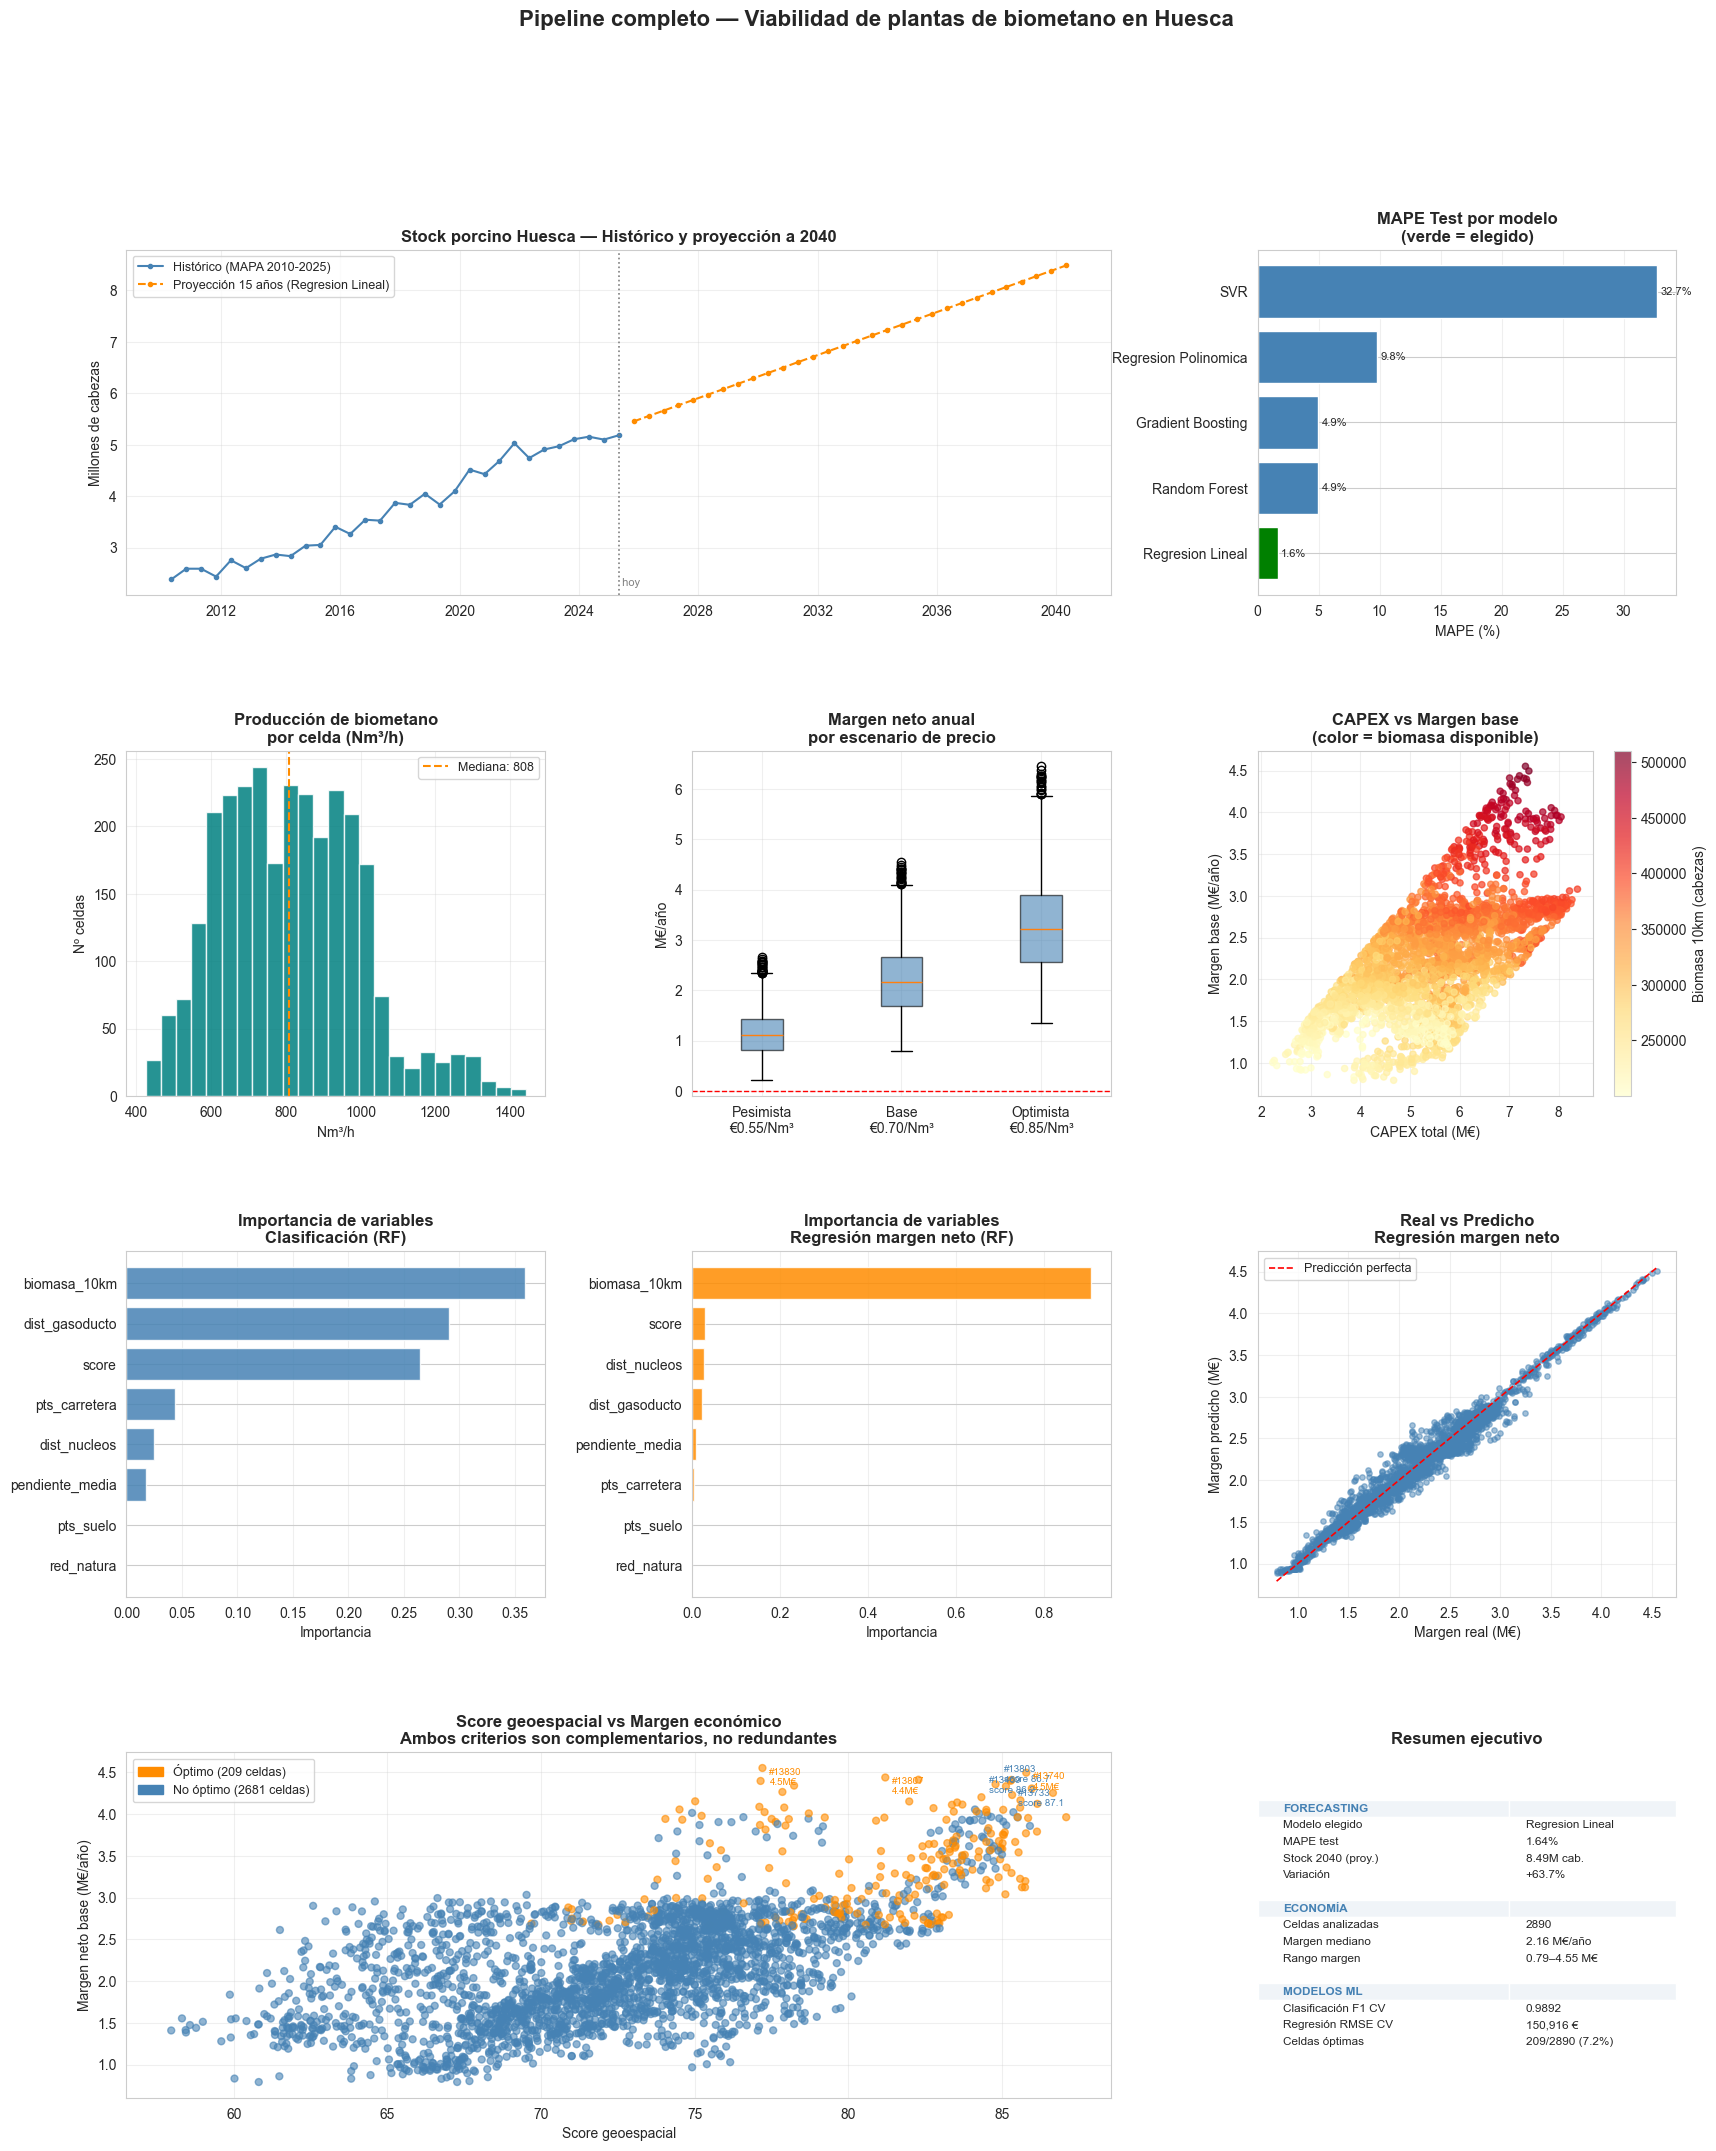

Guardado: data/processed/dashboard_pipeline_completo.png


In [17]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

n_opt = int(df_viab["viable"].sum())
n_no  = len(df_viab) - n_opt

fig = plt.figure(figsize=(20, 24))
fig.suptitle("Pipeline completo — Viabilidad de plantas de biometano en Huesca",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── BLOQUE 1: FORECASTING ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(serie["ds"].to_numpy(), (serie["y"] / 1e6).to_numpy(),
         marker="o", markersize=3, color="steelblue", label="Histórico (MAPA 2010-2025)")
ax1.plot(futuro["ds"].to_numpy(), (futuro["yhat"] / 1e6).to_numpy(),
         marker="o", markersize=3, linestyle="--", color="darkorange",
         label=f"Proyección 15 años ({mejor_modelo_nombre})")
ax1.axvline(x=serie["ds"].iloc[-1], color="gray", linestyle=":", linewidth=1.2)
y_min = (serie["y"].min() / 1e6) * 0.95
ax1.text(serie["ds"].iloc[-1], y_min, " hoy", color="gray", fontsize=8)
ax1.set_title("Stock porcino Huesca — Histórico y proyección a 2040", fontweight="bold")
ax1.set_ylabel("Millones de cabezas")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
colores_mape = ["green" if m == mejor_modelo_nombre else "steelblue"
                for m in resultados_finales["modelo"]]
bars = ax2.barh(resultados_finales["modelo"].to_numpy(),
                resultados_finales["MAPE_TEST"].to_numpy(), color=colores_mape)
ax2.set_title("MAPE Test por modelo\n(verde = elegido)", fontweight="bold")
ax2.set_xlabel("MAPE (%)")
for bar, val in zip(bars, resultados_finales["MAPE_TEST"].to_numpy()):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=8)
ax2.grid(alpha=0.3, axis="x")

# ── BLOQUE 2: ECONOMÍA ─────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(df_viab["biometano_Nm3h"].to_numpy(), bins=25,
         color="teal", edgecolor="white", alpha=0.85)
ax3.axvline(df_viab["biometano_Nm3h"].median(), color="darkorange",
            linestyle="--", linewidth=1.5,
            label=f"Mediana: {df_viab['biometano_Nm3h'].median():.0f}")
ax3.set_title("Producción de biometano\npor celda (Nm³/h)", fontweight="bold")
ax3.set_xlabel("Nm³/h"); ax3.set_ylabel("Nº celdas")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
datos_box = [(df_viab["margen_pesimista_€"] / 1e6).to_numpy(),
             (df_viab["margen_base_€"] / 1e6).to_numpy(),
             (df_viab["margen_optimista_€"] / 1e6).to_numpy()]
ax4.boxplot(datos_box,
            labels=["Pesimista\n€0.55/Nm³", "Base\n€0.70/Nm³", "Optimista\n€0.85/Nm³"],
            patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
ax4.axhline(0, color="red", linestyle="--", linewidth=1)
ax4.set_title("Margen neto anual\npor escenario de precio", fontweight="bold")
ax4.set_ylabel("M€/año"); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 2])
sc = ax5.scatter(df_viab["capex_total_M€"].to_numpy(),
                 (df_viab["margen_base_€"] / 1e6).to_numpy(),
                 c=df_viab["biomasa_10km"].to_numpy(),
                 cmap="YlOrRd", alpha=0.7, s=20)
plt.colorbar(sc, ax=ax5, label="Biomasa 10km (cabezas)")
ax5.set_title("CAPEX vs Margen base\n(color = biomasa disponible)", fontweight="bold")
ax5.set_xlabel("CAPEX total (M€)"); ax5.set_ylabel("Margen base (M€/año)")
ax5.grid(alpha=0.3)

# ── BLOQUE 3: MODELOS ML ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0])
imp_clf = pd.DataFrame({"feature": FEATURES,
                         "importancia": best_clf.feature_importances_})\
            .sort_values("importancia")
ax6.barh(imp_clf["feature"].to_numpy(), imp_clf["importancia"].to_numpy(),
         color="steelblue", alpha=0.85)
ax6.set_title("Importancia de variables\nClasificación (RF)", fontweight="bold")
ax6.set_xlabel("Importancia"); ax6.grid(alpha=0.3, axis="x")

ax7 = fig.add_subplot(gs[2, 1])
imp_reg = pd.DataFrame({"feature": FEATURES,
                         "importancia": best_reg.feature_importances_})\
            .sort_values("importancia")
ax7.barh(imp_reg["feature"].to_numpy(), imp_reg["importancia"].to_numpy(),
         color="darkorange", alpha=0.85)
ax7.set_title("Importancia de variables\nRegresión margen neto (RF)", fontweight="bold")
ax7.set_xlabel("Importancia"); ax7.grid(alpha=0.3, axis="x")

ax8 = fig.add_subplot(gs[2, 2])
ax8.scatter((df_viab["margen_base_€"] / 1e6).to_numpy(),
            (df_viab["margen_pred_€"] / 1e6).to_numpy(),
            alpha=0.5, s=15, color="steelblue")
lim_min = min(df_viab["margen_base_€"].min(), df_viab["margen_pred_€"].min()) / 1e6
lim_max = max(df_viab["margen_base_€"].max(), df_viab["margen_pred_€"].max()) / 1e6
ax8.plot([lim_min, lim_max], [lim_min, lim_max], "r--",
         linewidth=1.2, label="Predicción perfecta")
ax8.set_title("Real vs Predicho\nRegresión margen neto", fontweight="bold")
ax8.set_xlabel("Margen real (M€)"); ax8.set_ylabel("Margen predicho (M€)")
ax8.legend(fontsize=9); ax8.grid(alpha=0.3)

# ── BLOQUE 4: SCORE VS ECONOMÍA ────────────────────────────────────
ax9 = fig.add_subplot(gs[3, :2])
colores_t = df_viab["viable"].map({0: "steelblue", 1: "darkorange"}).to_numpy()
ax9.scatter(df_viab["score"].to_numpy(),
            (df_viab["margen_base_€"] / 1e6).to_numpy(),
            c=colores_t, alpha=0.6, s=25)

for _, row in df_viab.nlargest(3, "score").iterrows():
    ax9.annotate(f"#{int(row['cell_id'])}\nscore {row['score']:.1f}",
                 (row["score"], row["margen_base_€"] / 1e6),
                 textcoords="offset points", xytext=(-35, 8),
                 fontsize=7, color="steelblue")

for _, row in df_viab.nlargest(3, "margen_base_€").iterrows():
    ax9.annotate(f"#{int(row['cell_id'])}\n{row['margen_base_M€']:.1f}M€",
                 (row["score"], row["margen_base_€"] / 1e6),
                 textcoords="offset points", xytext=(5, -12),
                 fontsize=7, color="darkorange")

ax9.legend(handles=[Patch(color="darkorange", label=f"Óptimo ({n_opt} celdas)"),
                    Patch(color="steelblue",   label=f"No óptimo ({n_no} celdas)")],
           fontsize=9)
ax9.set_title("Score geoespacial vs Margen económico\n"
              "Ambos criterios son complementarios, no redundantes",
              fontweight="bold")
ax9.set_xlabel("Score geoespacial")
ax9.set_ylabel("Margen neto base (M€/año)")
ax9.grid(alpha=0.3)

ax10 = fig.add_subplot(gs[3, 2])
ax10.axis("off")
resumen = [
    ["FORECASTING", ""],
    ["Modelo elegido", mejor_modelo_nombre],
    ["MAPE test", f"{mape_final:.2f}%"],
    ["Stock 2040 (proy.)", f"{stock_proy_15a/1e6:.2f}M cab."],
    ["Variación", f"{variacion_pct:+.1f}%"],
    ["", ""],
    ["ECONOMÍA", ""],
    ["Celdas analizadas", f"{len(df_viab)}"],
    ["Margen mediano", f"{df_viab['margen_base_€'].median()/1e6:.2f} M€/año"],
    ["Rango margen", f"{df_viab['margen_base_€'].min()/1e6:.2f}–{df_viab['margen_base_€'].max()/1e6:.2f} M€"],
    ["", ""],
    ["MODELOS ML", ""],
    ["Clasificación F1 CV", f"{f1_cv.mean():.4f}"],
    ["Regresión RMSE CV", f"{rmse_cv.mean():,.0f} €"],
    ["Celdas óptimas", f"{n_opt}/{len(df_viab)} ({df_viab['viable'].mean()*100:.1f}%)"],
]
tabla = ax10.table(cellText=resumen, cellLoc="left",
                   loc="center", colWidths=[0.6, 0.4])
tabla.auto_set_font_size(False)
tabla.set_fontsize(8.5)
for (row, col), cell in tabla.get_celld().items():
    cell.set_edgecolor("white")
    if resumen[row][0] in ["FORECASTING", "ECONOMÍA", "MODELOS ML"]:
        cell.set_text_props(fontweight="bold", color="steelblue")
        cell.set_facecolor("#f0f4f8")
    else:
        cell.set_facecolor("white")
ax10.set_title("Resumen ejecutivo", fontweight="bold")

plt.savefig(DIR_PROCESSED / "dashboard_pipeline_completo.png", dpi=130, bbox_inches="tight")
plt.show()
print("Guardado: data/processed/dashboard_pipeline_completo.png")

In [48]:
# Mapa interactivo de las celdas óptimas (se abre como HTML en el navegador)
import pydeck as pdk



ruta_salida = DIR_PROCESSED / "mapa_optimas_biometano.html"
ruta_huesca = DIR_DELIM / "Huesca_Delimitacion.geojson"

viables_proj   = viables.to_crs("EPSG:25830").copy()
centroides_wgs = viables_proj.geometry.centroid.to_crs("EPSG:4326")
viables_wgs    = viables_proj.to_crs("EPSG:4326").copy()
viables_wgs["lon"] = centroides_wgs.x
viables_wgs["lat"] = centroides_wgs.y

cols_merge = ["cell_id", "viable", "margen_base_M€", "biometano_Nm3h",
              "capex_total_M€", "stock_proyectado_15a", "score"]
cols_drop = [c for c in cols_merge if c in viables_wgs.columns and c != "cell_id"]
if cols_drop:
    viables_wgs = viables_wgs.drop(columns=cols_drop)
viables_wgs = viables_wgs.merge(df_viab[cols_merge], on="cell_id", how="left")

no_optimas = viables_wgs[viables_wgs["viable"] == 0].copy()
optimas    = viables_wgs[viables_wgs["viable"] == 1].copy()

# Gradiente de color y radio proporcional al margen
margen_min = optimas["margen_base_M€"].min()
margen_max = optimas["margen_base_M€"].max()

def color_margen(m, mn, mx):
    t = (m - mn) / (mx - mn) if mx != mn else 0.5
    return [int(200 + 55 * t), int(160 * (1 - t)), 20, 220]

optimas["radio"] = (300 + 400 * (optimas["margen_base_M€"] - margen_min)
                    / (margen_max - margen_min)).round(0)
optimas["color"] = optimas["margen_base_M€"].apply(
    lambda m: color_margen(m, margen_min, margen_max))

if ruta_huesca.exists():
    huesca = gpd.read_file(ruta_huesca).to_crs("EPSG:4326")
else:
    print("Huesca_Delimitacion.geojson no encontrado — uso el contorno de las celdas.")
    huesca = viables_wgs.dissolve().reset_index(drop=True)

huesca_geojson = json.loads(huesca[["geometry"]].to_json())

no_optimas_pdk = pd.DataFrame(no_optimas.drop(columns="geometry"))
optimas_pdk    = pd.DataFrame(optimas.drop(columns="geometry"))

layer_huesca = pdk.Layer(
    "GeoJsonLayer", data=huesca_geojson,
    stroked=True, filled=True,
    get_fill_color=[240, 240, 235, 60],
    get_line_color=[100, 100, 100, 180],
    line_width_min_pixels=1.5,
)
layer_no_optimas = pdk.Layer(
    "ScatterplotLayer", data=no_optimas_pdk,
    get_position=["lon", "lat"], get_radius=280,
    get_fill_color=[180, 180, 180, 100], pickable=False,
)
layer_optimas = pdk.Layer(
    "ScatterplotLayer", data=optimas_pdk,
    get_position=["lon", "lat"], get_radius="radio", get_fill_color="color",
    pickable=True, auto_highlight=True, highlight_color=[255, 255, 255, 180],
)

view = pdk.ViewState(latitude=42.00, longitude=-0.08, zoom=7.8, pitch=0, bearing=0)

tooltip = {
    "html": """
    <div style="font-family:sans-serif; font-size:12px; padding:4px;">
        <b style="font-size:13px;">Celda #{cell_id}</b><br/>
        <hr style="margin:4px 0; border-color:#ddd;"/>
        Score geoespacial: <b>{score}</b><br/>
        Biometano: <b>{biometano_Nm3h} Nm³/h</b><br/>
        Margen base: <b>{margen_base_M€} M€/año</b><br/>
        CAPEX total: <b>{capex_total_M€} M€</b><br/>
        Stock proy. 2040: <b>{stock_proyectado_15a}</b>
    </div>""",
    "style": {"backgroundColor": "white", "color": "#222",
              "border": "1px solid #ccc", "borderRadius": "8px",
              "padding": "6px", "boxShadow": "0 2px 8px rgba(0,0,0,0.15)"}
}

leyenda = f"""
<div style="position:absolute; bottom:30px; left:20px; background:white;
            padding:14px 18px; border-radius:10px; font-family:sans-serif;
            font-size:12px; box-shadow:0 2px 10px rgba(0,0,0,0.2); z-index:1000;
            min-width:260px;">
    <div style="font-weight:bold; font-size:14px; margin-bottom:10px; color:#222;">
        Plantas de biometano — Huesca
    </div>
    <div style="margin-bottom:8px; color:#555; font-size:11px;">
        Óptimas: viabilidad geoespacial + económica + proyección 15 años
    </div>
    <div style="display:flex; align-items:center; margin-bottom:6px;">
        <div style="width:14px; height:14px; border-radius:50%;
                    background:rgba(255,60,20,0.85); margin-right:8px;"></div>
        <span>Óptima — margen alto</span>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:6px;">
        <div style="width:12px; height:12px; border-radius:50%;
                    background:rgba(220,120,20,0.85); margin-right:8px;"></div>
        <span>Óptima — margen medio ({len(optimas)} en total)</span>
    </div>
    <div style="display:flex; align-items:center; margin-bottom:10px;">
        <div style="width:10px; height:10px; border-radius:50%;
                    background:rgba(180,180,180,0.6); margin-right:8px;"></div>
        <span>Viable no óptima ({len(no_optimas)} celdas)</span>
    </div>
    <div style="border-top:1px solid #eee; padding-top:8px; font-size:11px; color:#888;">
        Clic en punto naranja/rojo para ver detalle
    </div>
</div>"""

deck = pdk.Deck(
    layers=[layer_huesca, layer_no_optimas, layer_optimas],
    initial_view_state=view, tooltip=tooltip,
    map_style="https://basemaps.cartocdn.com/gl/positron-gl-style/style.json",
    description=leyenda
)

deck.to_html(str(ruta_salida))
print(f"Guardado: {ruta_salida.relative_to(RAIZ)}")
print(f"  Óptimas:            {len(optimas)} celdas")
print(f"  Viables no óptimas: {len(no_optimas)} celdas")
print(f"  Rango margen:       {margen_min:.2f} – {margen_max:.2f} M€/año")


Guardado: data\processed\mapa_optimas_biometano.html
  Óptimas:            209 celdas
  Viables no óptimas: 2681 celdas
  Rango margen:       2.66 – 4.55 M€/año


## 4. Estudio financiero: Monte Carlo sobre todas las celdas optimas

Hasta acá el margen era una cuenta determinista con tres escenarios de precio, que sirve para filtrar celdas pero no para decidir si conviene poner plata. Para eso, sobre **todas las celdas óptimas** de la sección 3 — no un top fijo — aplicamos el análisis financiero completo:

- **Solo datos actuales.** El purín que entra al modelo es el que existe hoy alrededor de cada celda, constante los 15 años. 
- **El tamaño de la planta no viene fijado.** Para cada localización probamos tres escalas (pequeña, mediana y grande) y nos quedamos con la de mejor VAN esperado. Donde hay biomasa de sobra gana la grande por economía de escala; donde no, una mediana evita cargar con un CAPEX que quedaría medio vacío.
- **Todo lo incierto se modela.** En vez de escenarios fijos corremos miles de simulaciones de Monte Carlo sobre 8 variables clave, con distribuciones triangulares deliberadamente prudentes. El resultado no es *un* VAN sino la distribución completa del VAN — y con eso podemos responder cuánta probabilidad hay de perder plata.
- **La planta no arranca al 100%.** Metemos una curva de arranque realista: 60% de producción los primeros años, subiendo hasta el 100% recién en el año 10. Rodar los digestores y cerrar los contratos de purín granja a granja lleva tiempo, y esa caja que se atrasa pesa mucho al descontarla.



In [19]:
# Las localizaciones del estudio financiero son TODAS las óptimas de la
# sección 3. El purín bruto es el ACTUAL (sin proyección): el que existe
# físicamente hoy en 10 km; cuánto se moviliza de verdad lo decide el
# Monte Carlo con la variable "movilizacion".
optimas_fin = df_viab[df_viab["viable"] == 1].copy()

sitios = pd.DataFrame({
    "cell_id":             optimas_fin["cell_id"].astype(int),
    "score_idoneidad":     optimas_fin["score"],
    "purin_bruto_t_anio":  optimas_fin["purin_bruto_t_anio"],
    "dist_gasoducto_m":    optimas_fin["dist_gasoducto"],
    "dist_carretera_m":    optimas_fin["dist_carretera"],
    "pendiente_media_deg": optimas_fin["pendiente_media"],
    "red_natura":          optimas_fin["red_natura"],
    "pts_suelo":           optimas_fin["pts_suelo"],
}).reset_index(drop=True)

print(f"Localizaciones que pasan al estudio financiero: {len(sitios)}")
print("\n=== FEEDSTOCK BRUTO POR LOCALIZACIÓN (10 primeras por score) ===")
sitios.sort_values("score_idoneidad", ascending=False)\
      [["cell_id", "score_idoneidad", "purin_bruto_t_anio",
        "dist_gasoducto_m", "pendiente_media_deg"]].head(10)


Localizaciones que pasan al estudio financiero: 209

=== FEEDSTOCK BRUTO POR LOCALIZACIÓN (10 primeras por score) ===


,cell_id,score_idoneidad,purin_bruto_t_anio,dist_gasoducto_m,pendiente_media_deg
116,13733,87.10,"773,067.00",70.31,2.45
146,13803,86.67,"822,822.00",102.55,2.49
92,13469,86.16,"800,817.00",189.44,2.17
118,13735,86.15,"743,345.00",6.30,3.40
145,13802,85.98,"834,149.00",594.95,1.64
121,13738,85.86,"773,067.00",425.57,3.25
123,13740,85.80,"867,343.00",822.26,2.88
158,13849,85.79,"740,911.00",236.81,2.66
39,13179,85.77,"646,777.00","1,057.55",2.43
57,13270,85.76,"631,127.00",361.69,3.25


### 4.1 Parámetros fijos del modelo financiero

Costes y parámetros que dejamos fijos — a estos no les aplicamos Monte Carlo. Los supuestos compartidos con la economía preliminar (rendimiento central, costes de conexión y logística, OPEX fijo, vida útil) ya quedaron definidos en la sección 3.


In [20]:
# Financieros
WACC          = 0.08    # rendimiento mínimo exigido / coste del capital
TASA_IMPUESTO = 0.25
WORKING_CAPITAL_PCT_INGRESOS = 0.05

# Escalas de planta (€ CAPEX, Nm³/año de capacidad)
PLANTAS = {
    "Pequena": {"capex": 3_000_000,  "capacidad": 2_000_000},
    "Mediana": {"capex": 6_000_000,  "capacidad": 5_000_000},
    "Grande":  {"capex": 12_000_000, "capacidad": 10_000_000},
}

# Conexiones que solo usa el CAPEX geoespacial de esta sección
COSTE_ACCESO_CARRETERA_EUR_KM = 80_000
COSTE_ELEC_AGUA_FIJO          = 2 * 80_000 + 2 * 60_000   # 2 km elec + 2 km agua

print(f"Horizonte: {VIDA_UTIL} años · WACC {WACC:.0%} · el VAN se calcula año a año (curva de arranque)")
print(f"OPEX fijo base anual: {OPEX_FIJO_BASE:,.0f} €")


Horizonte: 15 años · WACC 8% · el VAN se calcula año a año (curva de arranque)
OPEX fijo base anual: 785,000 €


### 4.2 Las 8 variables inciertas

Cada una toma valores dentro de una distribución triangular (mínimo, más probable, máximo). Las centramos de forma deliberadamente prudente — preferimos que el modelo peque de conservador:

| Variable | Mín | Más probable | Máx | Por qué |
|---|---|---|---|---|
| Movilización del feedstock | 0.72 | 0.85 | 0.96 | Se contrata la mayoría del purín cercano, pero nunca todo |
| Rendimiento (Nm³/t) | 15 | 20 | 25 | Bien por debajo del 25 optimista de la versión anterior |
| Precio biometano (€/Nm³) | 0.55 | 0.70 | 0.85 | ≈70 €/MWh, mediana de mercado, con caída posible |
| GdOs (€/Nm³) | 0.02 | 0.045 | 0.07 | El mercado de garantías de origen es volátil |
| OPEX variable (€/Nm³) | 0.10 | 0.12 | 0.16 | Los costes casi siempre se desvían para arriba |
| Sobrecoste de obra (×CAPEX) | 1.00 | 1.03 | 1.12 | Las obras casi siempre se pasan de presupuesto |
| Subvenciones (€/año) | 0 | 70.000 | 110.000 | Depende de la política pública del momento |
| Co-productos CO₂ + digestato (€/año) | 80.000 | 150.000 | 240.000 | Ingreso secundario, incierto |

Los valores de la columna **más probable** son exactamente los que usó la economía preliminar de la sección 3 — el filtro de óptimas y el estudio financiero comparten supuestos.


In [21]:
DIST = {
    "movilizacion": (0.72, 0.85, 0.96),
    "rendimiento":  (15.0, 20.0, 25.0),
    "precio":       (0.55, 0.70, 0.85),
    "gdos":         (0.02, 0.045, 0.07),
    "opex_var":     (0.10, 0.12, 0.16),
    "capex_overrun":(1.00, 1.03, 1.12),
    "subvenciones": (0.0, 70_000.0, 110_000.0),
    "coproductos":  (80_000.0, 150_000.0, 240_000.0),   # CO2 + digestato
}

def muestrear(nombre, n):
    lo, mo, hi = DIST[nombre]
    return rng.triangular(lo, mo, hi, size=n)

# Un vistazo a la pinta que tienen las muestras
demo = pd.DataFrame({k: muestrear(k, N_SIM) for k in DIST})
demo.describe().loc[["mean", "min", "25%", "50%", "75%", "max"]].round(3)

,movilizacion,rendimiento,precio,gdos,opex_var,capex_overrun,subvenciones,coproductos
mean,0.84,20.01,0.70,0.04,0.13,1.05,"60,151.08","156,336.60"
min,0.72,15.04,0.55,0.02,0.10,1.00,572.67,"80,504.22"
25%,0.81,18.55,0.66,0.04,0.12,1.03,"43,985.21","132,272.83"
50%,0.84,20.02,0.70,0.04,0.12,1.05,"62,319.89","154,415.33"
75%,0.88,21.47,0.74,0.05,0.14,1.07,"77,056.21","179,293.73"
max,0.96,24.98,0.85,0.07,0.16,1.12,"109,903.03","239,371.23"


### 4.3 Costes geoespaciales del CAPEX

Los extras de terreno (pendiente y ambiental) escalan con el CAPEX base, así que dependen del tamaño de planta. Las conexiones (gas, carretera, luz/agua) van por la distancia real de cada celda.

In [22]:
def capex_geoespacial(sitio, escala):
    capex_base = PLANTAS[escala]["capex"]

    # Pendiente: grados -> % (tangente del ángulo)
    pend_pct = np.tan(np.radians(sitio["pendiente_media_deg"])) * 100
    if pend_pct <= 5:      c_pend = capex_base * 0.01
    elif pend_pct <= 10:   c_pend = capex_base * 0.025
    else:                  c_pend = capex_base * 0.05

    # Ambiental (las óptimas ya sacaron Red Natura y suelo no apto -> restricción baja)
    c_amb = capex_base * 0.01

    # Conexiones por distancia real
    c_gas = (sitio["dist_gasoducto_m"] / 1000) * COSTE_CONEXION_GAS_EUR_KM
    c_car = (sitio["dist_carretera_m"] / 1000) * COSTE_ACCESO_CARRETERA_EUR_KM
    return c_pend + c_amb + c_gas + c_car + COSTE_ELEC_AGUA_FIJO

# OPEX ambiental anual (restricción baja)
OPEX_AMBIENTAL = 25_000

### 4.4 El motor de simulación — con curva de arranque

Para una localización y una escala dadas, esta función corre las simulaciones y devuelve las distribuciones de **VAN, TIR, payback y utilización**.

La curva de arranque: años 1-5 al 60% de régimen, subida escalonada hasta el 100% en el año 10, y de ahí en adelante a pleno. Una planta de biometano no produce al 100% desde el día uno — el arranque biológico de los digestores lleva meses y los contratos de purín se cierran granja a granja. Como el flujo de caja ya no es constante, el VAN, la TIR y el payback se calculan **año a año**, no con la fórmula de anualidad.

Si encima el feedstock movilizado no llena la planta, la utilización de régimen queda por debajo del 100% y con ella los ingresos. Ese doble efecto (arranque + infrautilización) es el que castiga a las plantas sobredimensionadas.

In [23]:
RAMP = np.array([0.60]*5 + [0.70, 0.80, 0.80, 0.90, 1.00] + [1.00]*5)
ANIOS = np.arange(1, VIDA_UTIL + 1)          # años 1..15
DESCUENTO = (1 + WACC) ** (-ANIOS)           # factor de descuento por año

def irr_flujos(capex, cf_years, lo=-0.9, hi=3.0, iters=90):
    # TIR de un flujo [-capex, cf_1, ..., cf_15] por bisección vectorizada
    capex = np.asarray(capex, float)
    n_draws = cf_years.shape[1]
    anios = ANIOS[:, None]
    lo = np.full(n_draws, lo); hi = np.full(n_draws, hi)
    for _ in range(iters):
        mid = (lo + hi) / 2
        disc = (1 + mid[None, :]) ** (-anios)          # (15, n_draws)
        npv = -capex + (cf_years * disc).sum(axis=0)
        lo = np.where(npv > 0, mid, lo)                # el NPV decrece con r
        hi = np.where(npv > 0, hi, mid)
    irr = (lo + hi) / 2
    return np.where(cf_years.sum(axis=0) > 0, irr, np.nan)

def simular(sitio, escala, draws):
    cap        = PLANTAS[escala]["capacidad"]
    capex_geo  = capex_geoespacial(sitio, escala)
    capex_base = PLANTAS[escala]["capex"]

    # Feedstock movilizado y producción de RÉGIMEN (año 10+), topada por capacidad
    purin_mov = sitio["purin_bruto_t_anio"] * draws["movilizacion"] * FACTOR_DISPONIBILIDAD
    biomet_potencial = purin_mov * draws["rendimiento"]
    produccion_regimen = np.minimum(cap, biomet_potencial)
    utilizacion = produccion_regimen / cap               # utilización a pleno rendimiento

    capex = (capex_base + capex_geo) * draws["capex_overrun"]

    # Componentes que no dependen del año
    opex_fijo = OPEX_FIJO_BASE + capex * MANTENIMIENTO_PCT_CAPEX
    deprec = capex / VIDA_UTIL
    coste_unit_feedstock = (DIST_MEDIA_FEEDSTOCK_KM * COSTE_TRANSPORTE_EUR_T_KM
                            + COSTE_PRETRATAMIENTO_EUR_T)

    # Flujo de caja AÑO A AÑO aplicando la curva de arranque -> matriz (15, n_draws)
    n_draws = produccion_regimen.shape[0]
    cf_years = np.empty((VIDA_UTIL, n_draws))
    for t, r in enumerate(RAMP):
        prod_t = produccion_regimen * r                  # producción del año t
        purin_proc_t = prod_t / draws["rendimiento"]     # solo se acarrea lo que se digiere
        # los ingresos ligados a producción escalan con la rampa; subvenciones fijas
        ingresos_t = (prod_t * draws["precio"] + prod_t * draws["gdos"]
                      + draws["coproductos"] * r + draws["subvenciones"])
        opex_var_t = purin_proc_t * coste_unit_feedstock + prod_t * draws["opex_var"]
        ebitda_t = ingresos_t - opex_var_t - opex_fijo
        ebit_t = ebitda_t - deprec
        impuesto_t = np.maximum(0, ebit_t * TASA_IMPUESTO)
        nopat_t = ebit_t - impuesto_t
        cf_years[t] = nopat_t + deprec - ingresos_t * WORKING_CAPITAL_PCT_INGRESOS

    # VAN = -CAPEX + suma de flujos descontados año a año
    npv = -capex + (cf_years * DESCUENTO[:, None]).sum(axis=0)

    # TIR sobre el vector real de flujos
    irr = irr_flujos(capex, cf_years)

    # Payback simple: primer año en que el acumulado de caja supera el CAPEX
    acum = np.cumsum(cf_years, axis=0)
    alcanzado = acum >= capex[None, :]
    payback = np.where(alcanzado.any(axis=0), alcanzado.argmax(axis=0) + 1.0, np.nan)

    return {"npv": npv, "irr": irr, "payback": payback,
            "utilizacion": utilizacion, "cf_regimen": cf_years[-1]}

print("Motor de Monte Carlo con curva de arranque definido.")
print("Curva de producción (% de régimen) por año:")
print("  " + "  ".join(f"a{t+1}:{int(r*100)}%" for t, r in enumerate(RAMP)))

Motor de Monte Carlo con curva de arranque definido.
Curva de producción (% de régimen) por año:
  a1:60%  a2:60%  a3:60%  a4:60%  a5:60%  a6:70%  a7:80%  a8:80%  a9:90%  a10:100%  a11:100%  a12:100%  a13:100%  a14:100%  a15:100%


### 4.5 ¿Qué tamaño de planta conviene en cada sitio?

Simulamos las tres escalas con **exactamente los mismos sorteos aleatorios** (así la comparación es justa) y nos quedamos con la que maximiza el VAN esperado.

Spoiler: la mayoría va a elegir Grande, y no es un error del modelo — es economía de escala. Los costes fijos (personal, seguros, administración) son casi los mismos tenga la planta el tamaño que tenga, así que la grande los diluye sobre más producción y gana casi siempre... mientras logre llenarse. La escala menor solo se impone donde la biomasa no da para llenar una grande.

In [24]:
def generar_draws(n):
    return {k: muestrear(k, n) for k in DIST}

resultados_mc = {}   # cell_id -> {"escala": elegida, "npv": distribución del VAN}
comparativa = []     # VAN medio y utilización de las tres escalas, por sitio
seleccion = []       # una fila por sitio, con su escala óptima

for j, (_, sitio) in enumerate(sitios.iterrows(), start=1):
    draws = generar_draws(N_SIM)
    por_escala = {esc: simular(sitio, esc, draws) for esc in PLANTAS}

    # criterio de selección: mayor VAN esperado (media)
    van_esperado = {esc: np.mean(r["npv"]) for esc, r in por_escala.items()}
    mejor_escala = max(van_esperado, key=van_esperado.get)
    r = por_escala[mejor_escala]

    fila = {"cell_id": sitio["cell_id"]}
    for esc, res in por_escala.items():
        fila[f"VAN_{esc}"]  = np.mean(res["npv"])
        fila[f"Util_{esc}"] = np.mean(res["utilizacion"])
    comparativa.append(fila)

    # Guardamos la distribución completa solo de la escala elegida: con
    # cientos de sitios, guardar las tres escalas se come la memoria.
    resultados_mc[sitio["cell_id"]] = {"escala": mejor_escala, "npv": r["npv"]}

    seleccion.append({
        "cell_id": sitio["cell_id"],
        "score_idoneidad": sitio["score_idoneidad"],
        "escala_optima": mejor_escala,
        "VAN_esperado": np.mean(r["npv"]),
        "VAN_p50": np.median(r["npv"]),
        "VAN_p5": np.percentile(r["npv"], 5),
        "VAN_p95": np.percentile(r["npv"], 95),
        "prob_VAN_positivo": np.mean(r["npv"] > 0),
        "prob_TIR_sobre_WACC": np.mean(r["irr"] > WACC),
        "TIR_p50": np.nanmedian(r["irr"]),
        "utilizacion_media": np.mean(r["utilizacion"]),
    })

    if j % 25 == 0 or j == len(sitios):
        print(f"  {j}/{len(sitios)} localizaciones simuladas")

df_sel  = pd.DataFrame(seleccion)
df_comp = pd.DataFrame(comparativa)
print("\n=== ESCALA ÓPTIMA POR LOCALIZACIÓN (máx. VAN esperado) ===")
print("Reparto de escalas:", df_sel["escala_optima"].value_counts().to_dict())
df_sel.head(15)


  25/209 localizaciones simuladas
  50/209 localizaciones simuladas
  75/209 localizaciones simuladas
  100/209 localizaciones simuladas
  125/209 localizaciones simuladas
  150/209 localizaciones simuladas
  175/209 localizaciones simuladas
  200/209 localizaciones simuladas
  209/209 localizaciones simuladas

=== ESCALA ÓPTIMA POR LOCALIZACIÓN (máx. VAN esperado) ===
Reparto de escalas: {'Grande': 167, 'Mediana': 42}


,cell_id,score_idoneidad,escala_optima,VAN_esperado,VAN_p50,VAN_p5,VAN_p95,prob_VAN_positivo,prob_TIR_sobre_WACC,TIR_p50,utilizacion_media
0,"5,280.00",73.37,Grande,"-766,965.38","-847,343.62","-6,671,353.64","5,302,490.02",0.41,0.41,0.07,0.87
1,"5,315.00",71.87,Mediana,"-1,683,275.39","-1,614,410.93","-4,452,572.67","904,994.64",0.15,0.15,0.05,1.00
2,"5,328.00",71.00,Grande,"-1,055,539.86","-1,161,810.07","-6,762,319.41","4,961,363.43",0.37,0.37,0.07,0.84
3,"5,330.00",69.69,Mediana,"-1,515,137.97","-1,460,948.38","-4,303,751.02","1,080,752.62",0.18,0.18,0.05,1.00
4,"5,345.00",72.23,Mediana,"-1,166,527.91","-1,124,095.31","-3,862,981.44","1,386,624.59",0.24,0.24,0.06,1.00
5,"5,346.00",72.49,Mediana,"-1,252,345.43","-1,220,372.35","-3,967,599.01","1,349,590.83",0.23,0.23,0.06,1.00
6,"5,347.00",78.58,Mediana,"-1,428,837.10","-1,373,832.72","-4,166,616.67","1,134,270.73",0.20,0.20,0.05,1.00
7,"5,348.00",79.79,Mediana,"-1,326,565.15","-1,281,877.92","-4,068,306.87","1,250,390.04",0.21,0.21,0.05,1.00
8,"5,349.00",79.55,Grande,"-1,184,824.94","-1,297,810.40","-6,976,897.14","4,918,117.74",0.37,0.37,0.07,0.84
9,"5,351.00",73.50,Mediana,"-1,403,411.47","-1,359,183.08","-4,177,767.30","1,157,518.01",0.20,0.20,0.05,1.00


In [25]:
# Comparativa: VAN esperado y utilización de las tres escalas en cada sitio,
# para ver por qué cada uno elige el tamaño que elige (df_comp se arma en el
# bucle de simulación).
vista = df_comp.copy()
for esc in PLANTAS:
    vista[f"VAN_{esc}"]  = (vista[f"VAN_{esc}"] / 1e6).round(2)
    vista[f"Util_{esc}"] = (vista[f"Util_{esc}"] * 100).round(0)
vista = vista.sort_values("VAN_Grande", ascending=False)
print(f"=== VAN ESPERADO (M€) Y UTILIZACIÓN (%) POR ESCALA — 15 primeras de {len(vista)} ===")
vista.head(15)


=== VAN ESPERADO (M€) Y UTILIZACIÓN (%) POR ESCALA — 15 primeras de 209 ===


,cell_id,VAN_Pequena,Util_Pequena,VAN_Mediana,Util_Mediana,VAN_Grande,Util_Grande
149,"13,806.00",-4.12,100.00,-0.97,100.00,2.36,100.00
146,"13,803.00",-4.16,100.00,-1.02,100.00,2.24,99.00
92,"13,469.00",-4.17,100.00,-1.02,100.00,2.20,99.00
152,"13,830.00",-4.30,100.00,-1.15,100.00,2.20,100.00
150,"13,807.00",-4.30,100.00,-1.14,100.00,2.19,100.00
151,"13,821.00",-4.36,100.00,-1.18,100.00,2.17,100.00
126,"13,743.00",-4.33,100.00,-1.17,100.00,2.14,100.00
145,"13,802.00",-4.33,100.00,-1.17,100.00,2.13,100.00
94,"13,482.00",-4.27,100.00,-1.11,100.00,2.09,99.00
157,"13,848.00",-4.20,100.00,-1.05,100.00,2.06,99.00


### 4.6 Métricas de riesgo por localización

In [26]:
tabla = df_sel.copy()
tabla["VAN_esperado_M"] = (tabla["VAN_esperado"] / 1e6).round(2)
tabla["VAN_p50_M"]      = (tabla["VAN_p50"] / 1e6).round(2)
tabla["VAN_p5_M"]       = (tabla["VAN_p5"] / 1e6).round(2)
tabla["VAN_p95_M"]      = (tabla["VAN_p95"] / 1e6).round(2)
tabla["P(VAN>0)"]       = (tabla["prob_VAN_positivo"] * 100).round(1)
tabla["P(TIR>WACC)"]    = (tabla["prob_TIR_sobre_WACC"] * 100).round(1)
tabla["TIR_p50_%"]      = (tabla["TIR_p50"] * 100).round(1)
tabla["Util_%"]         = (tabla["utilizacion_media"] * 100).round(0)

tabla = tabla.sort_values(["prob_VAN_positivo", "VAN_esperado"], ascending=False)
cols = ["cell_id", "escala_optima", "VAN_esperado_M", "VAN_p5_M", "VAN_p50_M", "VAN_p95_M",
        "P(VAN>0)", "P(TIR>WACC)", "TIR_p50_%", "Util_%"]
print(f"=== MÉTRICAS DE RIESGO (a la escala óptima de cada sitio) — 15 primeras de {len(tabla)} ===")
tabla[cols].head(15)


=== MÉTRICAS DE RIESGO (a la escala óptima de cada sitio) — 15 primeras de 209 ===


,cell_id,escala_optima,VAN_esperado_M,VAN_p5_M,VAN_p50_M,VAN_p95_M,P(VAN>0),P(TIR>WACC),TIR_p50_%,Util_%
149,"13,806.00",Grande,2.36,-2.64,2.37,7.44,76.90,76.90,10.40,100.00
146,"13,803.00",Grande,2.24,-2.86,2.24,7.34,75.70,75.70,10.30,99.00
152,"13,830.00",Grande,2.20,-2.86,2.23,7.23,75.30,75.30,10.20,100.00
151,"13,821.00",Grande,2.17,-2.95,2.19,7.25,75.20,75.20,10.20,100.00
150,"13,807.00",Grande,2.19,-2.83,2.16,7.26,75.10,75.10,10.20,100.00
92,"13,469.00",Grande,2.20,-2.98,2.22,7.39,74.90,74.90,10.20,99.00
126,"13,743.00",Grande,2.14,-2.96,2.14,7.31,74.90,74.90,10.10,100.00
145,"13,802.00",Grande,2.13,-2.94,2.15,7.18,74.90,74.90,10.20,100.00
94,"13,482.00",Grande,2.09,-3.12,2.11,7.28,73.90,73.90,10.10,99.00
144,"13,801.00",Grande,2.05,-3.09,2.08,7.12,73.60,73.60,10.10,99.00


### 4.7 Ranking ajustado a riesgo

Ordenamos por la **probabilidad de que el proyecto gane plata** — `P(VAN>0)` — y desempatamos por VAN esperado. Preferimos el proyecto que más seguro sale bien antes que el que promete más pero con más chance de salir mal.

In [27]:
ranking = df_sel.sort_values(["prob_VAN_positivo", "VAN_esperado"], ascending=False).reset_index(drop=True)
ranking.index = ranking.index + 1
ranking.index.name = "Rank"

rk = ranking.copy()
rk["VAN esperado (M€)"] = (rk["VAN_esperado"]/1e6).round(2)
rk["VAN P50 (M€)"]      = (rk["VAN_p50"]/1e6).round(2)
rk["P(VAN>0) %"]        = (rk["prob_VAN_positivo"]*100).round(1)
rk["P(TIR>WACC) %"]     = (rk["prob_TIR_sobre_WACC"]*100).round(1)
print(f"=== RANKING AJUSTADO A RIESGO — 15 primeros de {len(rk)} ===")
rk[["cell_id", "escala_optima", "VAN esperado (M€)", "VAN P50 (M€)", "P(VAN>0) %", "P(TIR>WACC) %"]].head(15)


=== RANKING AJUSTADO A RIESGO — 15 primeros de 209 ===


,cell_id,escala_optima,VAN esperado (M€),VAN P50 (M€),P(VAN>0) %,P(TIR>WACC) %
Rank,,,,,,
1,"13,806.00",Grande,2.36,2.37,76.90,76.90
2,"13,803.00",Grande,2.24,2.24,75.70,75.70
3,"13,830.00",Grande,2.20,2.23,75.30,75.30
4,"13,821.00",Grande,2.17,2.19,75.20,75.20
5,"13,807.00",Grande,2.19,2.16,75.10,75.10
6,"13,469.00",Grande,2.20,2.22,74.90,74.90
7,"13,743.00",Grande,2.14,2.14,74.90,74.90
8,"13,802.00",Grande,2.13,2.15,74.90,74.90
9,"13,482.00",Grande,2.09,2.11,73.90,73.90


### 4.8 Distribuciones del VAN

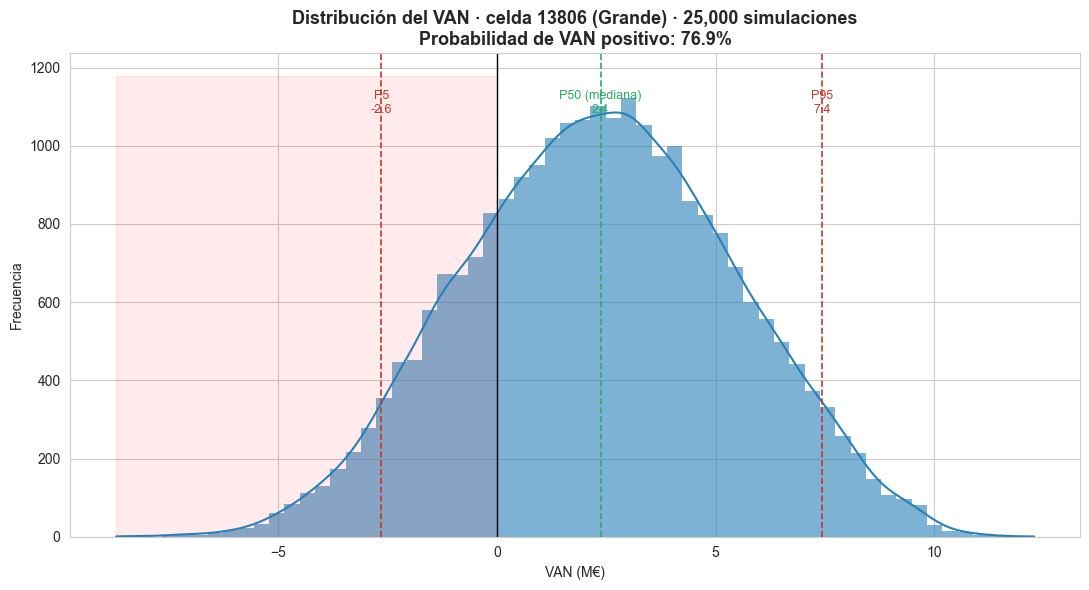

In [28]:
# Distribución del VAN de la mejor localización
mejor_cid = int(ranking.iloc[0]["cell_id"])
mejor_esc = ranking.iloc[0]["escala_optima"]
npv_mejor = resultados_mc[mejor_cid]["npv"] / 1e6

p5, p50, p95 = np.percentile(npv_mejor, [5, 50, 95])
prob_pos = np.mean(npv_mejor > 0) * 100

fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(npv_mejor, bins=60, kde=True, color="#2980b9", edgecolor="none", alpha=0.6, ax=ax)
ax.axvline(0, color="black", lw=1)
# sombrear la zona de pérdida
ymin, ymax = ax.get_ylim()
ax.fill_betweenx([0, ymax], npv_mejor.min(), 0, color="red", alpha=0.08)
for v, lab, col in [(p5,"P5","#c0392b"), (p50,"P50 (mediana)","#27ae60"), (p95,"P95","#c0392b")]:
    ax.axvline(v, color=col, ls="--", lw=1.2)
    ax.text(v, ymax*0.97, f"{lab}\n{v:.1f}", ha="center", va="top", fontsize=9, color=col)
ax.set_title(f"Distribución del VAN · celda {mejor_cid} ({mejor_esc}) · {N_SIM:,} simulaciones\n"
             f"Probabilidad de VAN positivo: {prob_pos:.1f}%", fontsize=13, weight="bold")
ax.set_xlabel("VAN (M€)"); ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "mc_distribucion_van_mejor.png", dpi=130, bbox_inches="tight")
plt.show()

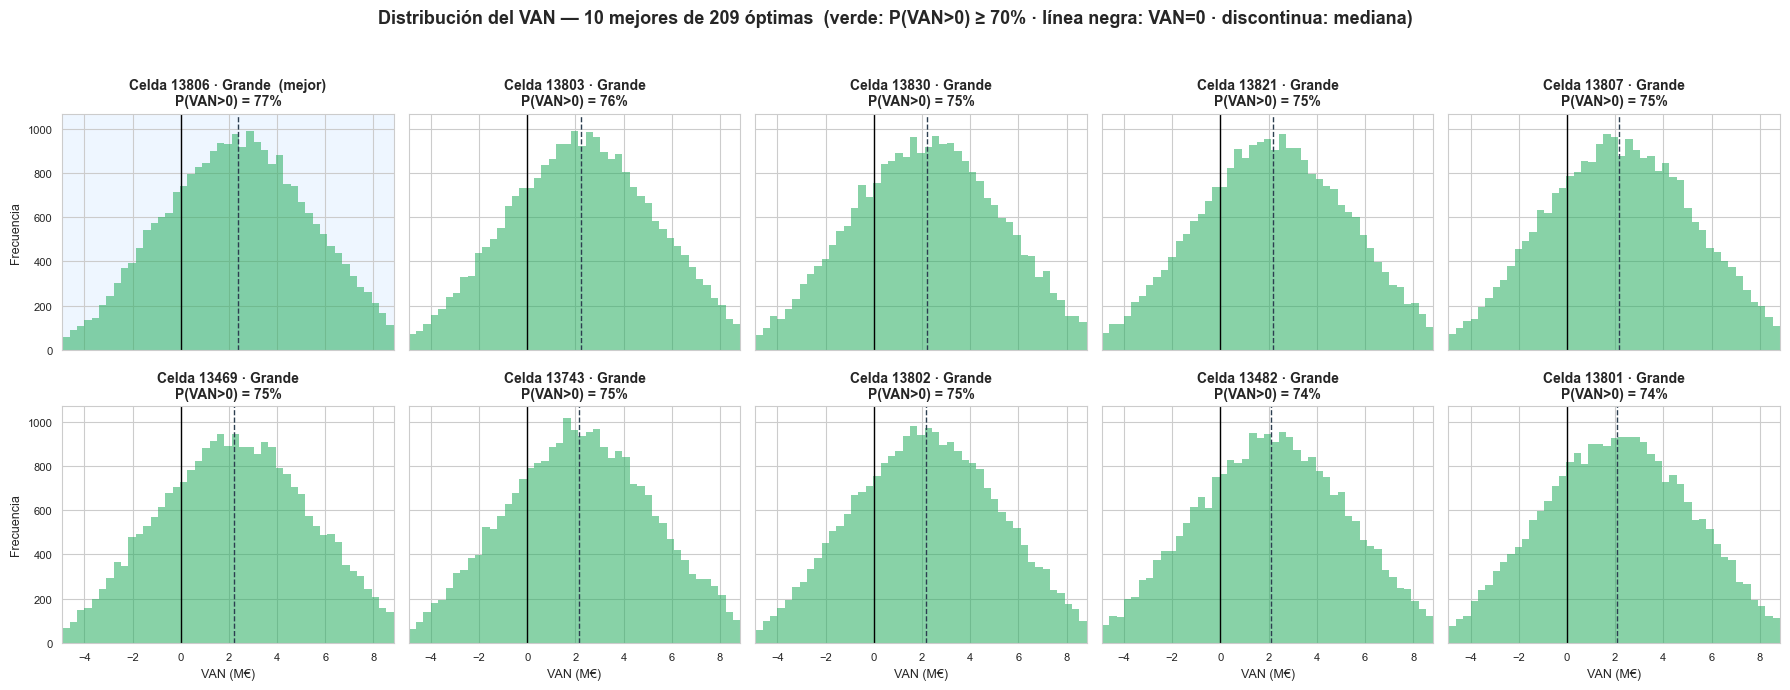

In [37]:
# Distribución del VAN de las 10 mejores localizaciones del ranking
orden_rk = ranking["cell_id"].tolist()[:20]            # top del ranking ajustado a riesgo
esc_por_sitio = df_sel.set_index("cell_id")["escala_optima"]

# Límites de X comunes para comparar todas en igualdad de condiciones
todos_npv = np.concatenate([resultados_mc[c]["npv"] / 1e6 for c in orden_rk])
xlo, xhi = np.percentile(todos_npv, [1, 99])

fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for k, (ax, cid) in enumerate(zip(axes.ravel(), orden_rk)):
    esc = esc_por_sitio[cid]
    npv = resultados_mc[cid]["npv"] / 1e6
    prob = np.mean(npv > 0) * 100
    color = "#27ae60" if prob >= 70 else "#c0392b"       # verde si es viable, rojo si no
    ax.hist(npv, bins=45, range=(xlo, xhi), color=color, alpha=0.55, edgecolor="none")
    ax.axvline(0, color="black", lw=1)
    ax.axvline(np.median(npv), color="#2c3e50", ls="--", lw=1)  # mediana
    corona = "  (mejor)" if k == 0 else ""
    ax.set_title(f"Celda {int(cid)} · {esc}{corona}\nP(VAN>0) = {prob:.0f}%", fontsize=10, weight="bold")
    ax.set_xlim(xlo, xhi); ax.tick_params(labelsize=8)

axes.ravel()[0].set_facecolor("#eef6ff")               # resaltar la mejor
for ax in axes[-1, :]: ax.set_xlabel("VAN (M€)", fontsize=9)
for ax in axes[:, 0]:  ax.set_ylabel("Frecuencia", fontsize=9)

fig.suptitle(f"Distribución del VAN — 10 mejores de {len(df_sel)} óptimas  "
             "(verde: P(VAN>0) ≥ 70% · línea negra: VAN=0 · discontinua: mediana)",
             fontsize=13, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(DIR_PROCESSED / "mc_distribucion_van_todas.png", dpi=130, bbox_inches="tight")
plt.show()


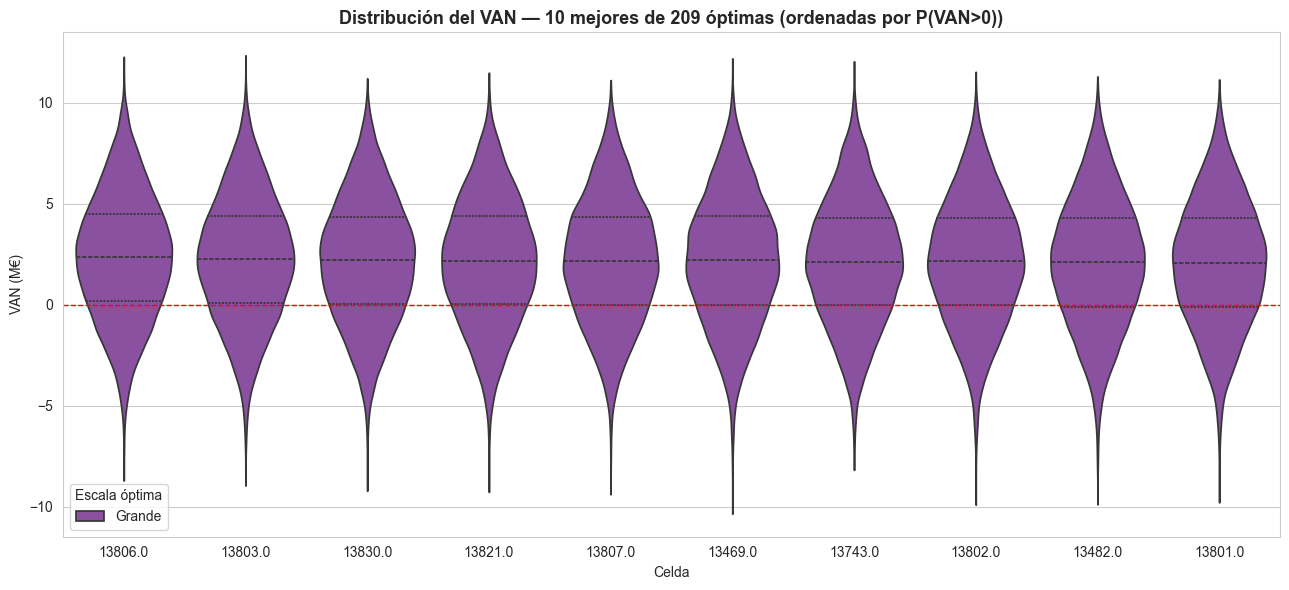

In [30]:
# Violines: comparativa de las distribuciones entre las 10 mejores localizaciones
orden = ranking["cell_id"].tolist()[:10]
data_violin = []
for cid in orden:
    esc = esc_por_sitio[cid]
    for v in resultados_mc[cid]["npv"] / 1e6:
        data_violin.append({"celda": str(cid), "VAN": v, "escala": esc})
df_violin = pd.DataFrame(data_violin)

fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=df_violin, x="celda", y="VAN", order=[str(c) for c in orden],
               hue="escala", palette={"Grande":"#8e44ad","Mediana":"#2980b9","Pequena":"#16a085"},
               dodge=False, inner="quartile", cut=0, ax=ax)
ax.axhline(0, color="red", lw=1, ls="--")
ax.set_title(f"Distribución del VAN — 10 mejores de {len(df_sel)} óptimas (ordenadas por P(VAN>0))",
             fontsize=13, weight="bold")
ax.set_xlabel("Celda"); ax.set_ylabel("VAN (M€)")
ax.legend(title="Escala óptima")
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "mc_violin_van_sitios.png", dpi=130, bbox_inches="tight")
plt.show()


C:\Users\FGonella\AppData\Local\Temp\ipykernel_27700\1045386074.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\FGonella\AppData\Local\Temp\ipykernel_27700\1045386074.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(DIR_PROCESSED / "mc_tornado_sensibilidad.png", dpi=130, bbox_inches="tight")
C:\Users\FGonella\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


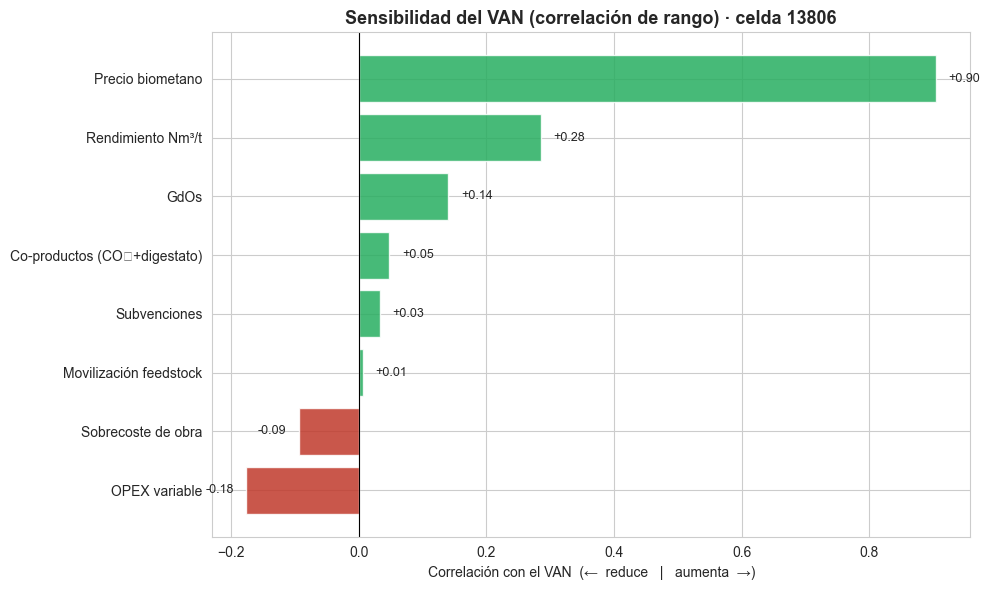

In [31]:
# Tornado: qué variable mueve más el VAN (en la mejor localización)
draws_ref = generar_draws(N_SIM)
res_ref = simular(sitios.set_index("cell_id").loc[mejor_cid], mejor_esc, draws_ref)
npv_ref = res_ref["npv"]

def rankdata(a):
    o = a.argsort(); r = np.empty_like(o, dtype=float); r[o] = np.arange(len(a)); return r

rank_npv = rankdata(npv_ref)
labels_es = {"precio":"Precio biometano", "movilizacion":"Movilización feedstock",
             "rendimiento":"Rendimiento Nm³/t", "opex_var":"OPEX variable",
             "capex_overrun":"Sobrecoste de obra", "gdos":"GdOs",
             "subvenciones":"Subvenciones", "coproductos":"Co-productos (CO₂+digestato)"}
corr = {labels_es[k]: np.corrcoef(rankdata(draws_ref[k]), rank_npv)[0, 1] for k in DIST}
corr = pd.Series(corr).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Sensibilidad del VAN (correlación de rango) · celda {mejor_cid}", fontsize=13, weight="bold")
ax.set_xlabel("Correlación con el VAN  (←  reduce   |   aumenta  →)")
for i, v in enumerate(corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), i, f"{v:+.2f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "mc_tornado_sensibilidad.png", dpi=130, bbox_inches="tight")
plt.show()

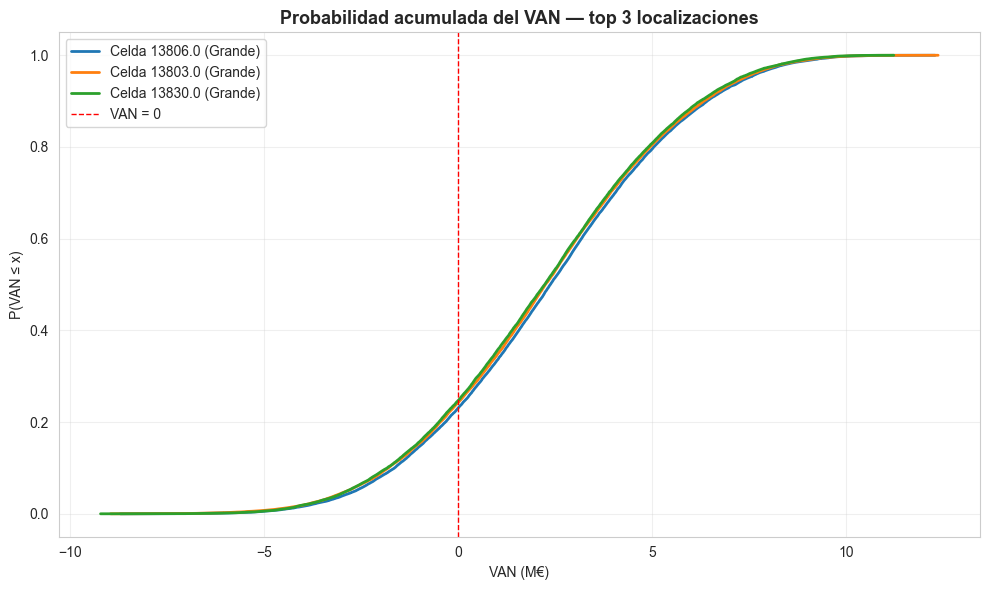

In [32]:
# Curva de probabilidad acumulada (riesgo de pérdida) — top 3 del ranking
fig, ax = plt.subplots(figsize=(10, 6))
for cid in orden[:3]:
    esc = esc_por_sitio[cid]
    x = np.sort(resultados_mc[cid]["npv"] / 1e6)
    y = np.arange(1, len(x)+1) / len(x)
    ax.plot(x, y, lw=2, label=f"Celda {cid} ({esc})")
ax.axvline(0, color="red", ls="--", lw=1, label="VAN = 0")
ax.set_title("Probabilidad acumulada del VAN — top 3 localizaciones", fontsize=13, weight="bold")
ax.set_xlabel("VAN (M€)"); ax.set_ylabel("P(VAN ≤ x)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "mc_cdf_van.png", dpi=130, bbox_inches="tight")
plt.show()


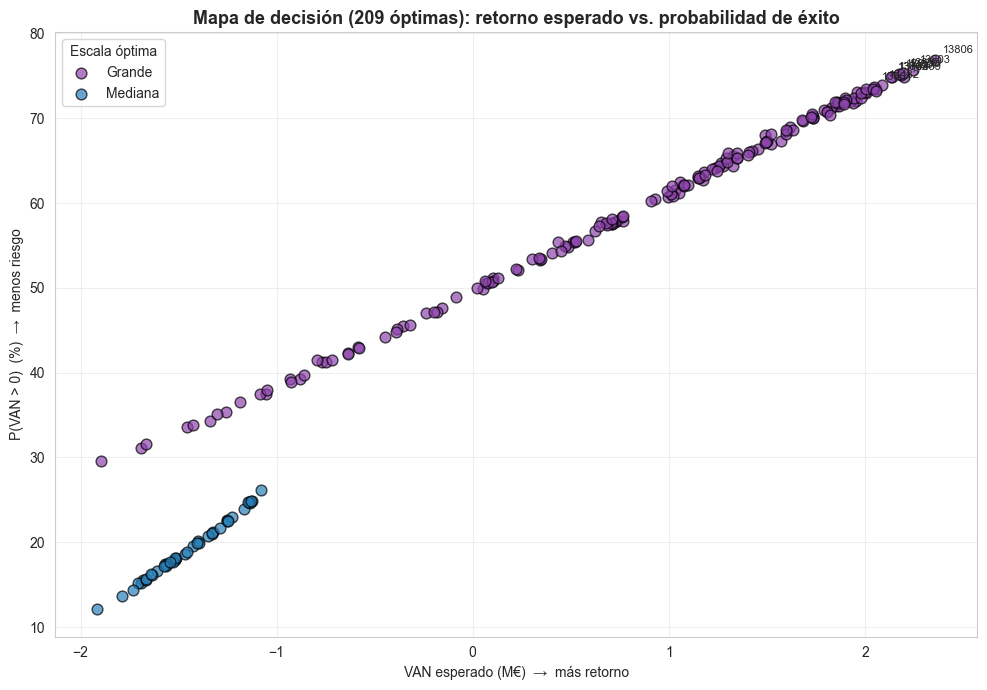

In [33]:
# Mapa de decisión: retorno esperado vs. probabilidad de éxito (todas las óptimas)
fig, ax = plt.subplots(figsize=(10, 7))
pal = {"Grande":"#8e44ad","Mediana":"#2980b9","Pequena":"#16a085"}
for esc in df_sel["escala_optima"].unique():
    sub = df_sel[df_sel["escala_optima"] == esc]
    ax.scatter(sub["VAN_esperado"]/1e6, sub["prob_VAN_positivo"]*100,
               s=60, color=pal[esc], edgecolors="black", alpha=0.7, label=esc)

# Etiquetamos solo el top 10 del ranking para no saturar el gráfico
top_ids = set(ranking["cell_id"].tolist()[:10])
for _, r in df_sel[df_sel["cell_id"].isin(top_ids)].iterrows():
    ax.annotate(int(r["cell_id"]), (r["VAN_esperado"]/1e6, r["prob_VAN_positivo"]*100),
                fontsize=8, xytext=(5,5), textcoords="offset points")
ax.set_title(f"Mapa de decisión ({len(df_sel)} óptimas): retorno esperado vs. probabilidad de éxito",
             fontsize=13, weight="bold")
ax.set_xlabel("VAN esperado (M€)  →  más retorno")
ax.set_ylabel("P(VAN > 0)  (%)  →  menos riesgo")
ax.legend(title="Escala óptima"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(DIR_PROCESSED / "mc_mapa_decision.png", dpi=130, bbox_inches="tight")
plt.show()


### 4.9 ¿A qué precio se vuelve rentable?

El tornado lo deja claro: la variable que más mueve el VAN es el precio del biometano. Entonces la pregunta obligada es *¿a qué precio de venta el proyecto empieza a ganar plata?*

Para la mejor localización — y con la curva de arranque puesta — calculamos el precio que lleva el VAN esperado a cero (break-even) y el que da una probabilidad de éxito del 75% (una apuesta ya cómoda). El resto de las variables se mantiene incierto.

Mejor localización: celda 13806 (Grande)
Precio break-even (VAN esperado = 0) : 0.648 €/Nm³
Precio para P(VAN>0) = 75%           : 0.666 €/Nm³
Precio central asumido               : 0.70 €/Nm³


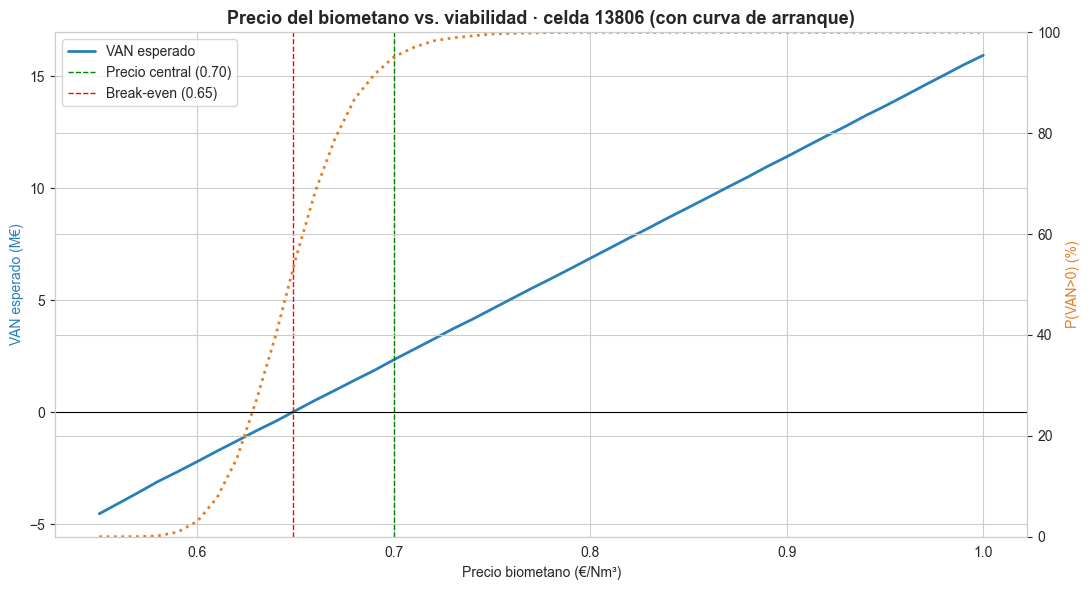

In [34]:
sitio_m = sitios.set_index("cell_id").loc[mejor_cid]

precios = np.arange(0.55, 1.001, 0.01)
van_esp, prob_pos = [], []
for p in precios:
    d = generar_draws(N_SIM)
    d["precio"] = np.full(N_SIM, p)          # fijamos el precio, el resto sigue incierto
    npv = simular(sitio_m, mejor_esc, d)["npv"]
    van_esp.append(np.mean(npv)); prob_pos.append(np.mean(npv > 0))
van_esp = np.array(van_esp); prob_pos = np.array(prob_pos)

def cruce(x, y, objetivo):
    i = np.argmax(y >= objetivo)
    if i == 0 and y[0] < objetivo: return np.nan
    if y[i] < objetivo: return np.nan
    if i == 0: return x[0]
    return x[i-1] + (objetivo - y[i-1]) * (x[i]-x[i-1]) / (y[i]-y[i-1])

precio_van0 = cruce(precios, van_esp, 0)
precio_p75  = cruce(precios, prob_pos, 0.75)
print(f"Mejor localización: celda {mejor_cid} ({mejor_esc})")
print(f"Precio break-even (VAN esperado = 0) : {precio_van0:.3f} €/Nm³")
print(f"Precio para P(VAN>0) = 75%           : {precio_p75:.3f} €/Nm³")
print(f"Precio central asumido               : 0.70 €/Nm³")

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.plot(precios, van_esp/1e6, color="#2980b9", lw=2, label="VAN esperado")
ax1.axhline(0, color="black", lw=0.8)
ax1.axvline(0.70, color="green", ls="--", lw=1, label="Precio central (0.70)")
if not np.isnan(precio_van0):
    ax1.axvline(precio_van0, color="red", ls="--", lw=1, label=f"Break-even ({precio_van0:.2f})")
ax1.set_xlabel("Precio biometano (€/Nm³)"); ax1.set_ylabel("VAN esperado (M€)", color="#2980b9")
ax2 = ax1.twinx()
ax2.plot(precios, prob_pos*100, color="#e67e22", lw=2, ls=":", label="P(VAN>0)")
ax2.set_ylabel("P(VAN>0) (%)", color="#e67e22"); ax2.set_ylim(0, 100)
ax1.set_title(f"Precio del biometano vs. viabilidad · celda {mejor_cid} (con curva de arranque)",
              fontsize=13, weight="bold")
ax1.legend(loc="upper left"); plt.tight_layout()
plt.savefig(DIR_PROCESSED / "mc_breakeven_precio.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Exportar resultados

In [39]:
df_sel.to_csv(DIR_PROCESSED / "viabilidad_final_montecarlo_optimas.csv", index=False)

geo = viables[["cell_id", "score", "geometry"]].merge(
    df_sel[["cell_id", "escala_optima", "VAN_esperado", "VAN_p50",
            "prob_VAN_positivo", "prob_TIR_sobre_WACC"]],
    on="cell_id", how="inner")
geo.to_file(DIR_PROCESSED / "viabilidad_final_montecarlo_optimas.gpkg", driver="GPKG")
print(f"Guardado: viabilidad_final_montecarlo_optimas.csv / .gpkg "
      f"({len(geo)} localizaciones) + gráficos PNG en data/processed")

df_sel.loc[df_sel['escala_optima']=='Mediana']

Guardado: viabilidad_final_montecarlo_optimas.csv / .gpkg (209 localizaciones) + gráficos PNG en data/processed


,cell_id,score_idoneidad,escala_optima,VAN_esperado,VAN_p50,VAN_p5,VAN_p95,prob_VAN_positivo,prob_TIR_sobre_WACC,TIR_p50,utilizacion_media
1,"5,315.00",71.87,Mediana,"-1,683,275.39","-1,614,410.93","-4,452,572.67","904,994.64",0.15,0.15,0.05,1.00
3,"5,330.00",69.69,Mediana,"-1,515,137.97","-1,460,948.38","-4,303,751.02","1,080,752.62",0.18,0.18,0.05,1.00
4,"5,345.00",72.23,Mediana,"-1,166,527.91","-1,124,095.31","-3,862,981.44","1,386,624.59",0.24,0.24,0.06,1.00
5,"5,346.00",72.49,Mediana,"-1,252,345.43","-1,220,372.35","-3,967,599.01","1,349,590.83",0.23,0.23,0.06,1.00
6,"5,347.00",78.58,Mediana,"-1,428,837.10","-1,373,832.72","-4,166,616.67","1,134,270.73",0.20,0.20,0.05,1.00
7,"5,348.00",79.79,Mediana,"-1,326,565.15","-1,281,877.92","-4,068,306.87","1,250,390.04",0.21,0.21,0.05,1.00
9,"5,351.00",73.50,Mediana,"-1,403,411.47","-1,359,183.08","-4,177,767.30","1,157,518.01",0.20,0.20,0.05,1.00
12,"5,364.00",70.98,Mediana,"-1,394,683.36","-1,340,828.33","-4,171,272.80","1,208,732.60",0.20,0.20,0.05,1.00
13,"5,365.00",72.75,Mediana,"-1,407,350.33","-1,352,746.92","-4,162,615.95","1,170,038.07",0.20,0.20,0.05,1.00
14,"5,366.00",78.65,Mediana,"-1,569,572.57","-1,516,416.11","-4,328,162.10","1,025,090.70",0.17,0.17,0.05,1.00


## 6. Recomendación de inversión

In [52]:
mejor    = ranking.iloc[0]
p_exito  = mejor["prob_VAN_positivo"]
p_tir    = mejor["prob_TIR_sobre_WACC"]
reparto  = df_sel["escala_optima"].value_counts().to_dict()
n_ok     = int((df_sel["prob_VAN_positivo"] >= 0.5).sum())
var_top  = corr.abs().idxmax()

print("=" * 70)
print("  RECOMENDACIÓN DE INVERSIÓN — PLANTA DE BIOMETANO EN HUESCA")
print("=" * 70)
print(f'''
Universo analizado           : {len(df_viab)} celdas viables → {len(df_sel)} óptimas → Monte Carlo
Simulaciones por sitio       : {N_SIM:,} (x 3 escalas)
Sitios con P(VAN>0) >= 50%   : {n_ok}/{len(df_sel)}
Reparto de escalas óptimas   : {reparto}

── Mejor candidata ──
Celda                        : {int(mejor['cell_id'])}
Escala recomendada           : {mejor['escala_optima']}
VAN esperado                 : {mejor['VAN_esperado']/1e6:.2f} M€
VAN mediana (P50)            : {mejor['VAN_p50']/1e6:.2f} M€
Rango probable (P5 – P95)    : {mejor['VAN_p5']/1e6:.1f} a {mejor['VAN_p95']/1e6:.1f} M€
P(VAN > 0)                   : {p_exito:.0%}
P(TIR > WACC)                : {p_tir:.0%}
Utilización media de planta  : {mejor['utilizacion_media']:.0%}

── Sensibilidad y precio ──
Variable que más mueve el VAN : {var_top}
Precio break-even             : {precio_van0:.2f} €/Nm³
Precio para P(éxito) = 75%    : {precio_p75:.2f} €/Nm³  (central asumido: 0.70)
''')

if p_exito >= 0.70:
    conclusion = (
        "INVERTIR. Incluso con supuestos prudentes, la probabilidad de éxito es alta.\n"
        "Conviene arrancar por la celda del puesto 1 del ranking, con la escala indicada,\n"
        "y asegurar contratos de purín antes de comprometer el CAPEX."
    )
elif p_exito >= 0.50:
    conclusion = (
        "INVERSIÓN CONDICIONADA. El proyecto está en zona gris: gana plata en la mitad\n"
        "de los futuros simulados, más o menos una moneda al aire. Antes de comprometer\n"
        "CAPEX hay que asegurar un contrato de venta (PPA) a un precio igual o mayor al\n"
        "break-even, o una subvención que cubra la diferencia. Con eso cerrado, la celda\n"
        "del puesto 1 del ranking es la candidata."
    )
else:
    conclusion = (
        "NO INVERTIR a los precios de mercado actuales. En la mayoría de los futuros\n"
        "simulados el proyecto pierde plata. Solo tiene sentido retomarlo si el precio\n"
        "del biometano se acerca al nivel que da 75% de éxito, o si aparece una\n"
        "subvención fuerte al CAPEX."
    )

print("Consusion Finaciera:")
print(conclusion)

  RECOMENDACIÓN DE INVERSIÓN — PLANTA DE BIOMETANO EN HUESCA

Universo analizado           : 2890 celdas viables → 209 óptimas → Monte Carlo
Simulaciones por sitio       : 25,000 (x 3 escalas)
Sitios con P(VAN>0) >= 50%   : 131/209
Reparto de escalas óptimas   : {'Grande': 167, 'Mediana': 42}

── Mejor candidata ──
Celda                        : 13806
Escala recomendada           : Grande
VAN esperado                 : 2.36 M€
VAN mediana (P50)            : 2.37 M€
Rango probable (P5 – P95)    : -2.6 a 7.4 M€
P(VAN > 0)                   : 77%
P(TIR > WACC)                : 77%
Utilización media de planta  : 100%

── Sensibilidad y precio ──
Variable que más mueve el VAN : Precio biometano
Precio break-even             : 0.65 €/Nm³
Precio para P(éxito) = 75%    : 0.67 €/Nm³  (central asumido: 0.70)

Consusion Finaciera:
INVERTIR. Incluso con supuestos prudentes, la probabilidad de éxito es alta.
Conviene arrancar por la celda del puesto 1 del ranking, con la escala indicada,
y asegurar

### Conclusiones finales


1. **La localización no es el problema.** El cruce del filtro geoespacial con la economía preliminar deja un conjunto sólido de celdas óptimas: biomasa de sobra en 10 km, gasoducto cerca y sin restricciones ambientales serias. La proyección del censo porcino a 2040 acompaña como señal de que la materia prima va a seguir estando — pero los números financieros se calcularon con el purín actual, así que si el censo crece, los resultados solo pueden mejorar.

2. **El negocio es una apuesta al precio.** El gráfico de tornado lo dice clarito: el VAN vive y muere con el precio del biometano (y en menor medida con las garantías de origen). Todo lo demás — rendimiento, movilización, sobrecostes de obra — mueve la aguja, pero no define el proyecto.

3. **El número a mirar no es el VAN, es P(VAN>0).** Un VAN esperado positivo con una probabilidad de pérdida cercana al 50% no es una inversión, es una moneda al aire. Por eso el ranking ordena por probabilidad de éxito, y la recomendación queda condicionada a asegurar el precio de venta (contrato a largo plazo o subvención).


